# Initialization

Please run all of the cells in this section before proceeding in the notebook. This will import all necessary packages and define functions used throughout the notebook.

## Imports

In [2]:
using SparseArrays, KrylovKit, LinearAlgebra, Plots, DataFrames, LsqFit, ProgressMeter, JLD, Optim, LaTeXStrings, Alert, Statistics

## Functions

In [3]:
function rot(origin, point, rot_angle)
    """
    Rotate a point counterclockwise by a given angle around a given origin.
    The angle should be given in radians.
    """
    ox, oy = origin
    px, py = point
    
    qx = ox + cos(rot_angle) * (px - ox) - sin(rot_angle) * (py - oy)
    qy = oy + sin(rot_angle) * (px - ox) + cos(rot_angle) * (py - oy)
    
    return [Int(round(qx)), Int(round(qy))]
end;

In [4]:
function idx(i,j)
    return (i-1)*L + j
end;

function idx_inv(x)
    return Int((x/L)-mod1(x,L)/L+1), mod1(x,L)
end;

In [5]:
function hamiltonian_pbc(L, tp, t, δϕ)
    rows = []
    cols = []
    data = Vector{Complex{Float64}}()
    
    for i in 1:L
        for j in 1:L
            # Nearest Neighbor
            if mod(j, 2) == 0 
                push!(rows, idx(mod1(i+1,L),j)); push!(cols, idx(i,j)); push!(data, -t);
                push!(cols, idx(mod1(i+1,L),j)); push!(rows, idx(i,j)); push!(data, -t);
            else 
                push!(rows, idx(mod1(i+1,L),j)); push!(cols, idx(i,j)); push!(data, t);
                push!(cols, idx(mod1(i+1,L),j)); push!(rows, idx(i,j)); push!(data, t);
            end

            push!(rows, idx(i,mod1(j+1,L))); push!(cols, idx(i,j)); push!(data, t);
            push!(cols, idx(i,mod1(j+1,L))); push!(rows, idx(i,j)); push!(data, t);
            
            # Next Nearest Neighbor
            if mod(j, 2) == 1
                push!(rows, idx(mod1(i+1,L),mod1(j+1,L))); push!(cols, idx(i,j)); push!(data, -tp/4*im);
                push!(cols, idx(mod1(i+1,L),mod1(j+1,L))); push!(rows, idx(i,j)); push!(data, tp/4*im);

                push!(rows, idx(mod1(i-1,L),mod1(j+1,L))); push!(cols, idx(i,j)); push!(data, tp/4*im);
                push!(cols, idx(mod1(i-1,L),mod1(j+1,L))); push!(rows, idx(i,j)); push!(data, -tp/4*im);

            else
                push!(rows, idx(mod1(i+1,L),mod1(j+1,L))); push!(cols, idx(i,j)); push!(data, tp/4*im);
                push!(cols, idx(mod1(i+1,L),mod1(j+1,L))); push!(rows, idx(i,j)); push!(data, -tp/4*im);

                push!(rows, idx(mod1(i-1,L),mod1(j+1,L))); push!(cols, idx(i,j)); push!(data, -tp/4*im);
                push!(cols, idx(mod1(i-1,L),mod1(j+1,L))); push!(rows, idx(i,j)); push!(data, tp/4*im);
            end
        end
    end
    
    H = SparseArrays.sparse(rows, cols, data, L^2, L^2)

    return H
end;

In [6]:
function visualize(h,t,tp,δϕ)
    
    p1 = plot(legend=false,size=(600,600))

    for i in 1:L
        for j in 1:L
            for ip in 1:L
                for jp in 1:L
                    idx1 = idx(i,j)
                    idx2 = idx(ip,jp)
                    if round(h[idx2,idx1],digits=8) == t
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:black)
                    end
                    if round(h[idx2,idx1],digits=8) == -t
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:red)
                    end
                    if (δϕ!=0)&&(h[idx2,idx1] == -t*exp(im*δϕ))
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:purple,arrow=true)
                    end

                    if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*2*δϕ))
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line+[0.3,0.3], y_line, linewidth=2,linecolor=:blue,arrow=true)
                    end
                    if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*3*δϕ))
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line+[0.25,0.25], linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line+[0.5,0.5], linewidth=2,linecolor=:blue,arrow=true)
                    end
                    if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*4*δϕ))
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line+[0.25,0.25], linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line+[0.5,0.5], linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line+[0.75,0.75], linewidth=2,linecolor=:blue,arrow=true)
                    end
                    
                    if (tp!=0)&&(round(h[idx2,idx1],digits=8) == tp/4*im)
                        x_line = [i,ip]; y_line = [j,jp];
                        plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:orange,arrow=true)
                        plot!(x_line, y_line, linewidth=2,linecolor=:orange)
                    end
                    
                    if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*δϕ))
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line, linewidth=2,linecolor=:blue)
                    end
                    if (tp!=0)&&(δϕ!=0)&&(h[idx2,idx1] == tp/4*im*exp(im*δϕ))
                        x_line = [i,ip]; y_line = [j,jp];
                        plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:darkorange2,arrow=true)
                        plot!(x_line, y_line, linewidth=2,linecolor=:darkorange2)
                    end
                    if (tp!=0)&&(δϕ!=0)&&(h[idx2,idx1] == tp/4*im*exp(-im*δϕ))
                        x_line = [i,ip]; y_line = [j,jp];
                        plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:gold,arrow=true)
                        plot!(x_line, y_line, linewidth=2,linecolor=:goldenrod1)
                    end
                end
            end
        end
    end
    
    scatter!([origin_A[1]],[origin_A[2]],marker=:xcross,markersize=5,markerstrokewidth=5)
    annotate!(origin_A[1] + 0.2, origin_A[2] + 0.2, text(L"A", :black, 14))

    scatter!([origin_B[1]],[origin_B[2]],marker=:xcross,markersize=5,markerstrokewidth=5)
    annotate!(origin_B[1] + 0.2, origin_B[2] + 0.2, text(L"B", :black, 14))
    
    plot(p1,layout=(1,1),size=(400,400),constrained_layout=true,axis=([], false))
end;

In [7]:
function hamiltonian_obc(L, tp, t, δϕ)
    rows = []
    cols = []
    data = Vector{Complex{Float64}}()
    
    for i in 1:L
        for j in 1:L
            # Nearest Neighbor
            if mod(j, 2) == 1
                if i+1 <= L 
                    push!(rows, idx(i+1,j)); push!(cols, idx(i,j)); push!(data, -t);
                    push!(cols, idx(i+1,j)); push!(rows, idx(i,j)); push!(data, -t);
                end
            else 
                if i+1 <= L 
                    push!(rows, idx(i+1,j)); push!(cols, idx(i,j)); push!(data, t);
                    push!(cols, idx(i+1,j)); push!(rows, idx(i,j)); push!(data, t);
                end
            end

            if j+1 <= L 
                if (j==L/2+1/2)&&(i>L/2+1/2)
                    push!(rows, idx(i,j+1)); push!(cols, idx(i,j)); push!(data, exp(-im*δϕ)*t);
                    push!(cols, idx(i,j+1)); push!(rows, idx(i,j)); push!(data, exp(im*δϕ)*t);
                else
                    push!(rows, idx(i,j+1)); push!(cols, idx(i,j)); push!(data, t);
                    push!(cols, idx(i,j+1)); push!(rows, idx(i,j)); push!(data, t);
                end
            end
            
            # Next Nearest Neighbor
            if (j==L/2+1/2)&&(i>L/2+1/2)
                if (i + 1 <= L && j + 1 <= L) 
                    push!(rows, idx(i+1,j+1)); push!(cols, idx(i,j)); push!(data, tp/4*im*exp(-im*δϕ));
                    push!(cols, idx(i+1,j+1)); push!(rows, idx(i,j)); push!(data, -tp/4*im*exp(im*δϕ));

                    # H[idx(i+1,j+1),idx(i,j)] = -tp/4*im 
                end
                
                if (i - 1 > 0)&&(j + 1 <= L)&&(i==L/2+3/2)
                    push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, -tp/4*im);
                    push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, tp/4*im);

                    # H[idx(i+1,j-1),idx(i,j)] = tp/4*im 
                end

                if (i - 1 > 0)&&(j + 1 <= L)&&(i>L/2+3/2)
                    push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, -tp/4*im*exp(-im*δϕ));
                    push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, tp/4*im*exp(im*δϕ));

                    # H[idx(i+1,j-1),idx(i,j)] = tp/4*im 
                end
        
            elseif mod(j, 2) == 1
                if (i + 1 <= L && j + 1 <= L) 
                    push!(rows, idx(i+1,j+1)); push!(cols, idx(i,j)); push!(data, tp/4*im);
                    push!(cols, idx(i+1,j+1)); push!(rows, idx(i,j)); push!(data, -tp/4*im);

                    # H[idx(i+1,j+1),idx(i,j)] = -tp/4*im 
                end

                if (i - 1 > 0 && j + 1 <= L) 
                    push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, -tp/4*im);
                    push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, tp/4*im);

                    # H[idx(i+1,j-1),idx(i,j)] = tp/4*im 
                end
            else
                if (i + 1 <= L && j + 1 <= L) 
                    push!(rows, idx(i+1,j+1)); push!(cols, idx(i,j)); push!(data, -tp/4*im);
                    push!(cols, idx(i+1,j+1)); push!(rows, idx(i,j)); push!(data, tp/4*im);

                    # H[idx(i+1,j+1),idx(i,j)] = tp/4*im 
                end

                if (i - 1 > 0 && j + 1 <= L)  
                    push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, tp/4*im);
                    push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, -tp/4*im);

                    # H[idx(i+1,j-1),idx(i,j)] = -tp/4*im 
                end
            end
        end
    end
    
    H = SparseArrays.sparse(rows, cols, data, L^2, L^2)

    return H
end;

In [8]:
function visualize_obc(h,t,tp,δϕ)
    
    p1 = plot(legend=false,size=(600,600))

    for i in 1:L
        for j in 1:L
            for ip in 1:L
                for jp in 1:L
                    idx1 = idx(i,j)
                    idx2 = idx(ip,jp)
                    if round(h[idx2,idx1],digits=8) == t
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:black)
                    end
                    if round(h[idx2,idx1],digits=8) == -t
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:red)
                    end
                    if (δϕ!=0)&&(h[idx2,idx1] == -t*exp(im*δϕ))
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:purple,arrow=true)
                    end

                    if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*2*δϕ))
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line+[0.3,0.3], y_line, linewidth=2,linecolor=:blue,arrow=true)
                    end
                    if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*3*δϕ))
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line+[0.25,0.25], linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line+[0.5,0.5], linewidth=2,linecolor=:blue,arrow=true)
                    end
                    if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*4*δϕ))
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line, y_line, linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line+[0.25,0.25], linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line+[0.5,0.5], linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line+[0.75,0.75], linewidth=2,linecolor=:blue,arrow=true)
                    end
                    
                    if (tp!=0)&&(round(h[idx2,idx1],digits=8) == tp/4*im)
                        x_line = [i,ip]; y_line = [j,jp];
                        plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:orange,arrow=true)
                        plot!(x_line, y_line, linewidth=2,linecolor=:orange)
                    end
                    
                    if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*δϕ))
                        x_line = [i,ip]
                        y_line = [j,jp]
                        plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:blue,arrow=true)
                        plot!(x_line, y_line, linewidth=2,linecolor=:blue)
                    end
                    if (tp!=0)&&(δϕ!=0)&&(h[idx2,idx1] == tp/4*im*exp(im*δϕ))
                        x_line = [i,ip]; y_line = [j,jp];
                        plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:darkorange2,arrow=true)
                        plot!(x_line, y_line, linewidth=2,linecolor=:darkorange2)
                    end
                    if (tp!=0)&&(δϕ!=0)&&(h[idx2,idx1] == tp/4*im*exp(-im*δϕ))
                        x_line = [i,ip]; y_line = [j,jp];
                        plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:gold,arrow=true)
                        plot!(x_line, y_line, linewidth=2,linecolor=:goldenrod1)
                    end
                end
            end
        end
    end
    
    scatter!([origin[1]],[origin[2]],marker=:xcross,markersize=5,markerstrokewidth=5)
    
    plot(p1,layout=(1,1),size=(400,400),constrained_layout=true,axis=([], false))
end;

In [9]:
function disc_idx(i,j,k)
    return (j-1)*Int(L/2-1/2)*3 + (i-1)*3 + k + 1
end;

function disc_idx_inv(x)
    k = mod1(x-1,3)
    i = Int(mod(x-1-k,3*Int(L/2-1/2))/3) + 1
    j = Int((x-1-(i-1)*3-k)/(Int(L/2-1/2)*3))+1
    return i,j,k
end;

In [212]:
function idx_to_3d(idx)
    i, j, k = disc_idx_inv(idx)
    if idx == 1
        return 0, 0, 0 

    else
        if k==1
            x = Int(L/2+1/2-i)
            y = 0
            z = j-1
            return x, y, z
        end

        if k==2
            x = j-1
            y = Int(L/2+1/2-i)
            z = 0 
            return x, y, z
        end

        if k==3
            x = 0
            y = j-1
            z = Int(L/2+1/2-i)
            return x, y, z
        end
    end
end;

In [11]:
function rotate_3d(α,β,γ)
    Rz = [  cos(α) -sin(α) 0
            sin(α)  cos(α) 0
            0       0      1]

    Ry = [  cos(β)  0  sin(β)
            0       1  0
            -sin(β) 0  cos(β)]

    Rx = [  1  0       0
            0  cos(γ) -sin(γ)
            0  sin(γ) cos(γ)]
   return Rx*Ry*Rz 
end;

In [218]:
function idx_to_2d(idx)
    x,y,z = idx_to_3d(idx)
    pt = rotate_3d(0,-pi/4,pi/4)*[x,y,z]
    return pt[1], pt[2]
end;

In [368]:
function visualize_disc(H_disc,tp,t,δϕ)
    δ = 0
    p1 = plot(legend=false,size=(600,600))

    for i in 1:Int(L/2-1/2)
        for j in 1:Int(L/2+1/2)
            for k in 1:3
                for ip in 1:Int(L/2-1/2)
                    for jp in 1:Int(L/2+1/2)
                        for kp in 1:3
                            idx1 = disc_idx(i,j,k)
                            idx2 = disc_idx(ip,jp,kp)
                            if H_disc[idx2,idx1] == t
                                x1, y1 = idx_to_2d(idx1)
                                x2, y2 = idx_to_2d(idx2)
                                x_line = [x1,x2]
                                y_line = [y1,y2]
                                plot!(x_line, y_line, linewidth=2,linecolor=:black)
                            end
                            if H_disc[idx2,idx1] == -t
                                x1, y1 = idx_to_2d(idx1)
                                x2, y2 = idx_to_2d(idx2)
                                x_line = [x1,x2]
                                y_line = [y1,y2]
                                plot!(x_line, y_line, linewidth=2,linecolor=:red)
                            end
                            if (δϕ!=0)&&(H_disc[idx2,idx1] == -t*exp(im*δϕ))
                                x1, y1 = idx_to_2d(idx1)
                                x2, y2 = idx_to_2d(idx2)
                                x_line = [x1,x2]
                                y_line = [y1,y2]
                                plot!(x_line, y_line, linewidth=2,linecolor=:purple,arrow=true)
                            end
                            if (δϕ!=0)&&(H_disc[idx2,idx1] == t*exp(im*δϕ))
                                x1, y1 = idx_to_2d(idx1)
                                x2, y2 = idx_to_2d(idx2)
                                x_line = [x1,x2]
                                y_line = [y1,y2]
                                plot!(x_line, y_line, linewidth=2,linecolor=:blue,arrow=false)
                                plot!([x1,x1+0.8*(x2-x1)], [y1,y1+0.8*(y2-y1)], linewidth=2,linecolor=:blue,arrow=true)
                            end
                            if (tp!=0)&&(H_disc[idx2,idx1] == im*tp/4)
                                x1, y1 = idx_to_2d(idx1)
                                x2, y2 = idx_to_2d(idx2)
                                x_line = [x1,x2]
                                y_line = [y1,y2]
                                plot!(x_line, y_line, linewidth=2,linecolor=:orange,arrow=false)
                                plot!([x1,x1+0.8*(x2-x1)], [y1,y1+0.8*(y2-y1)], linewidth=2,linecolor=:orange,arrow=true)
                            end
                            if (δϕ!=0)&&(tp!=0)&&(H_disc[idx2,idx1] == im*tp/4*exp(im*δϕ))
                                x1, y1 = idx_to_2d(idx1)
                                x2, y2 = idx_to_2d(idx2)
                                x_line = [x1,x2]
                                y_line = [y1,y2]
                                plot!(x_line, y_line, linewidth=2,linecolor=:darkorange,arrow=false)
                                plot!([x1,x1+0.8*(x2-x1)], [y1,y1+0.8*(y2-y1)], linewidth=2,linecolor=:darkorange2,arrow=true)
                            end
                            if (δϕ!=0)&&(tp!=0)&&(H_disc[idx2,idx1] == im*tp/4*exp(-im*δϕ))
                                x1, y1 = idx_to_2d(idx1)
                                x2, y2 = idx_to_2d(idx2)
                                x_line = [x1,x2]
                                y_line = [y1,y2]
                                plot!(x_line, y_line, linewidth=2,linecolor=:gold,arrow=false)
                                plot!([x1,x1+0.8*(x2-x1)], [y1,y1+0.8*(y2-y1)], linewidth=2,linecolor=:gold,arrow=true)
                            end
                        end
                    end
                end
            end
        end
    end

    for i in 1:Int(L/2-1/2)
        for j in 1:Int(L/2+1/2)
            for k in 1:3
                idx1 = disc_idx(i,j,k)
                idx2 = 1
                if H_disc[idx2,idx1] == t
                    x1, y1 = idx_to_2d(idx1)
                    x2, y2 = 0,0
                    x_line = [x1,x2]
                    y_line = [y1,y2]
                    plot!(x_line, y_line, linewidth=2,linecolor=:black)
                end
                
                if H_disc[idx2,idx1] == -t
                    x1, y1 = idx_to_2d(idx1)
                    x2, y2 = 0,0
                    x_line = [x1,x2]
                    y_line = [y1,y2]
                    plot!(x_line, y_line, linewidth=2,linecolor=:red)
                end
                
                if (tp!=0)&&(H_disc[idx2,idx1] == im*tp/4)
                    x1, y1 = idx_to_2d(idx1)
                    x2, y2 = idx_to_2d(idx2)
                    x_line = [x1,x2]
                    y_line = [y1,y2]
                    plot!(x_line, y_line, linewidth=2,linecolor=:orange,arrow=false)
                    plot!([x1,x1+0.8*(x2-x1)], [y1,y1+0.8*(y2-y1)], linewidth=2,linecolor=:orange,arrow=true)
                elseif (tp!=0)&&(H_disc[idx2,idx1] == -im*tp/4)
                    x2, y2 = idx_to_2d(idx1)
                    x1, y1 = idx_to_2d(idx2)
                    x_line = [x2,x1]
                    y_line = [y2,y1]
                    plot!(x_line, y_line, linewidth=2,linecolor=:orange,arrow=false)
                    plot!([x1,x1+0.8*(x2-x1)], [y1,y1+0.8*(y2-y1)], linewidth=2,linecolor=:orange,arrow=true)
                end
            end
        end
    end
    
    for i in 1:Int(L/2-1/2)
        for j in 1:Int(L/2+1/2)
            for k in 1:3
                idx1 = disc_idx(i,j,k)
                if δ != 0
                    if H_disc[idx1,idx1] == δ
                        x, y = idx_to_2d(idx1)
                        scatter!([x],[y], color =:white, label = "", markersize = 10)
                    end
                    if H_disc[idx1,idx1] == -δ
                        x, y = idx_to_2d(idx1)
                        scatter!([x],[y], color =:black, label = "", markersize = 10)
                    end
                    if H_disc[1,1] == δ
                        scatter!([0],[0], color =:white, label = "", markersize = 10)
                    end
                end
            end
        end
    end
    
    plot(p1,size=(800,900),constrained_layout=true,axis=([], false))
end;

In [653]:
function disc_hamiltonian_A(L, tp, t, δϕ)
    rows = []
    cols = []
    data = Vector{Complex{Float64}}()
    
    ### BLOCK 1 ###
    for i in 1:Int(L/2-1/2)
        # Connect Blocks 1 and 2
        # Nearest Neighbor
        push!(rows, disc_idx(i,1,1)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,2)); push!(data, t*exp(-im*δϕ));
        push!(cols, disc_idx(i,1,1)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,2)); push!(data, t*exp(im*δϕ));
        
        # Next-Nearest Neighbor
        if i < Int(L/2-1/2)
            push!(rows, disc_idx(i,1,1)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,2)); push!(data, -im*tp/4*exp(-im*δϕ));
            push!(cols, disc_idx(i,1,1)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,2)); push!(data, im*tp/4*exp(im*δϕ));

            push!(rows, disc_idx(i+1,1,1)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,2)); push!(data, im*tp/4*exp(-im*δϕ));
            push!(cols, disc_idx(i+1,1,1)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,2)); push!(data, -im*tp/4*exp(im*δϕ));
        end
        
        for j in 1:Int(L/2+1/2)
            # Nearest Neighbor
            if mod(j, 2) == 0
                if i+1 <= Int(L/2-1/2) 
                    push!(rows, disc_idx(i+1,j,1)); push!(cols, disc_idx(i,j,1)); push!(data, -t);
                    push!(cols, disc_idx(i+1,j,1)); push!(rows, disc_idx(i,j,1)); push!(data, -t);
                end
            else 
                if i+1 <= Int(L/2-1/2) 
                    push!(rows, disc_idx(i+1,j,1)); push!(cols, disc_idx(i,j,1)); push!(data, t);
                    push!(cols, disc_idx(i+1,j,1)); push!(rows, disc_idx(i,j,1)); push!(data, t);
                end
            end

            if j+1 <= Int(L/2+1/2) 
                push!(rows, disc_idx(i,j+1,1)); push!(cols, disc_idx(i,j,1)); push!(data, t);
                push!(cols, disc_idx(i,j+1,1)); push!(rows, disc_idx(i,j,1)); push!(data, t);
            end
            
            # Next-Nearest Neighbor
            if (i+1 <= Int(L/2-1/2))
                if (j+1 <= Int(L/2+1/2))
                    push!(rows, disc_idx(i+1,j+1,1)); push!(cols, disc_idx(i,j,1)); push!(data, ((-1)^j)*im*tp/4);
                    push!(cols, disc_idx(i+1,j+1,1)); push!(rows, disc_idx(i,j,1)); push!(data, ((-1)^j)*(-im*tp/4));
                end
                if (j > 1)
                    push!(rows, disc_idx(i+1,j-1,1)); push!(cols, disc_idx(i,j,1)); push!(data, ((-1)^j)*(-im*tp/4));
                    push!(cols, disc_idx(i+1,j-1,1)); push!(rows, disc_idx(i,j,1)); push!(data, ((-1)^j)*im*tp/4);
                end   
            end
        end
    end
    
    ### BLOCK 2 ###
    for i in 1:Int(L/2-1/2)
        # Connect Blocks 2 and 3
        # Nearest Neighbor
        push!(rows, disc_idx(i,1,2)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,3)); push!(data, t);
        push!(cols, disc_idx(i,1,2)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,3)); push!(data, t);
        
        # Next-Nearest Neighbor
        if i<Int(L/2-1/2)
            push!(rows, disc_idx(i,1,2)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,3)); push!(data, (-im*tp/4));
            push!(cols, disc_idx(i,1,2)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,3)); push!(data, (im*tp/4));

            push!(rows, disc_idx(i+1,1,2)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,3)); push!(data, (im*tp/4));
            push!(cols, disc_idx(i+1,1,2)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,3)); push!(data, (-im*tp/4));
        end
        
        for j in 1:Int(L/2+1/2)
            # Nearest Neighbor
            if mod(i, 2) == 0
                if j+1 <= Int(L/2+1/2) 
                    push!(rows, disc_idx(i,j+1,2)); push!(cols, disc_idx(i,j,2)); push!(data, -t);
                    push!(cols, disc_idx(i,j+1,2)); push!(rows, disc_idx(i,j,2)); push!(data, -t);
                end
            else 
                if j+1 <= Int(L/2+1/2) 
                    push!(rows, disc_idx(i,j+1,2)); push!(cols, disc_idx(i,j,2)); push!(data, t);
                    push!(cols, disc_idx(i,j+1,2)); push!(rows, disc_idx(i,j,2)); push!(data, t);
                end
            end

            if i + 1 <= Int(L/2-1/2) 
                push!(rows, disc_idx(i+1,j,2)); push!(cols, disc_idx(i,j,2)); push!(data, t);
                push!(cols, disc_idx(i+1,j,2)); push!(rows, disc_idx(i,j,2)); push!(data, t);
            end
            
            # Next-Nearest Neighbor
            if (i+1 <= Int(L/2-1/2))
                if (j+1 <= Int(L/2+1/2))
                    push!(rows, disc_idx(i+1,j+1,2)); push!(cols, disc_idx(i,j,2)); push!(data, ((-1)^i)*(-im*tp/4));
                    push!(cols, disc_idx(i+1,j+1,2)); push!(rows, disc_idx(i,j,2)); push!(data, ((-1)^i)*(im*tp/4));
                end
                if (j > 1)
                    push!(rows, disc_idx(i+1,j-1,2)); push!(cols, disc_idx(i,j,2)); push!(data, ((-1)^i)*(im*tp/4));
                    push!(cols, disc_idx(i+1,j-1,2)); push!(rows, disc_idx(i,j,2)); push!(data, ((-1)^i)*(-im*tp/4));
                end   
            end
        end
    end
    
    ### BLOCK 3 ###
    for i in 1:Int(L/2-1/2)
        # Connect Blocks 3 and 1
        # Nearest Neighbor
        push!(rows, disc_idx(i,1,3)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,1)); push!(data, (-1)^(i+1)*t);
        push!(cols, disc_idx(i,1,3)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,1)); push!(data, (-1)^(i+1)*t);
        
        # Next-Nearest Neighbor
        if i < Int(L/2-1/2)
            push!(rows, disc_idx(i,1,3)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,1)); push!(data, ((-1)^(i+1))*(im*tp/4));
            push!(cols, disc_idx(i,1,3)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,1)); push!(data, ((-1)^(i+1))*(-im*tp/4));

            push!(rows, disc_idx(i+1,1,3)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,1)); push!(data, ((-1)^(i+1))*(im*tp/4));
            push!(cols, disc_idx(i+1,1,3)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,1)); push!(data, ((-1)^(i+1))*(-im*tp/4));
        end
        
        for j in 1:Int(L/2+1/2)
            # Nearest Neighbor
            if mod(i, 2) == 0
                if j+1 <= Int(L/2+1/2) 
                    push!(rows, disc_idx(i,j+1,3)); push!(cols, disc_idx(i,j,3)); push!(data, -t);
                    push!(cols, disc_idx(i,j+1,3)); push!(rows, disc_idx(i,j,3)); push!(data, -t);
                end
            else 
                if j+1 <= Int(L/2+1/2) 
                    push!(rows, disc_idx(i,j+1,3)); push!(cols, disc_idx(i,j,3)); push!(data, t);
                    push!(cols, disc_idx(i,j+1,3)); push!(rows, disc_idx(i,j,3)); push!(data, t);
                end
            end

            if i + 1 <= Int(L/2-1/2) 
                push!(rows, disc_idx(i+1,j,3)); push!(cols, disc_idx(i,j,3)); push!(data, t);
                push!(cols, disc_idx(i+1,j,3)); push!(rows, disc_idx(i,j,3)); push!(data, t);
            end
            
            # Next-Nearest Neighbor
            if (i+1 <= Int(L/2-1/2))
                if (j+1 <= Int(L/2+1/2))
                    push!(rows, disc_idx(i+1,j+1,3)); push!(cols, disc_idx(i,j,3)); push!(data, ((-1)^(i+1))*im*tp/4);
                    push!(cols, disc_idx(i+1,j+1,3)); push!(rows, disc_idx(i,j,3)); push!(data, ((-1)^(i+1))*(-im*tp/4));
                end
                if (j > 1)
                    push!(rows, disc_idx(i+1,j-1,3)); push!(cols, disc_idx(i,j,3)); push!(data, ((-1)^(i+1))*(-im*tp/4));
                    push!(cols, disc_idx(i+1,j-1,3)); push!(rows, disc_idx(i,j,3)); push!(data, ((-1)^(i+1))*im*tp/4);
                end   
            end
        end
    end
    
    ## ORIGIN ###
    # Nearest Neighbor
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),1,1)); push!(data, t);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),1,1)); push!(data, t);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),1,2)); push!(data, t);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),1,2)); push!(data, t);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),1,3)); push!(data, t);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),1,3)); push!(data, t);
    
    # Next-Nearest Neighbor
    push!(rows, disc_idx(Int(L/2-1/2),1,2)); push!(cols, disc_idx(Int(L/2-1/2),1,1)); push!(data, im*tp/4);
    push!(cols, disc_idx(Int(L/2-1/2),1,2)); push!(rows, disc_idx(Int(L/2-1/2),1,1)); push!(data, -im*tp/4);
    
    push!(rows, disc_idx(Int(L/2-1/2),1,3)); push!(cols, disc_idx(Int(L/2-1/2),1,2)); push!(data, im*tp/4);
    push!(cols, disc_idx(Int(L/2-1/2),1,3)); push!(rows, disc_idx(Int(L/2-1/2),1,2)); push!(data, -im*tp/4);
    
    push!(rows, disc_idx(Int(L/2-1/2),1,1)); push!(cols, disc_idx(Int(L/2-1/2),1,3)); push!(data, im*tp/4);
    push!(cols, disc_idx(Int(L/2-1/2),1,1)); push!(rows, disc_idx(Int(L/2-1/2),1,3)); push!(data, -im*tp/4);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),2,1)); push!(data, -im*tp/4);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),2,1)); push!(data, im*tp/4);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),2,2)); push!(data, im*tp/4);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),2,2)); push!(data, -im*tp/4);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),2,3)); push!(data, im*tp/4);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),2,3)); push!(data, -im*tp/4);
    
    
    H = SparseArrays.sparse(rows, cols, data, 3*Int(L/2+1/2)*Int(L/2-1/2)+1, 3*Int(L/2+1/2)*Int(L/2-1/2)+1)

    return H
end;

In [592]:
function disc_hamiltonian_B(L, tp, t, δϕ)
    rows = []
    cols = []
    data = Vector{Complex{Float64}}()
    
    ### BLOCK 1 ###
    for i in 1:Int(L/2-1/2)
        # Connect Blocks 1 and 2
        # Nearest Neighbor
        push!(rows, disc_idx(i,1,1)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,2)); push!(data, t*exp(-im*δϕ));
        push!(cols, disc_idx(i,1,1)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,2)); push!(data, t*exp(im*δϕ));
        
        # Next-Nearest Neighbor
        if i < Int(L/2-1/2)
            push!(rows, disc_idx(i,1,1)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,2)); push!(data, im*tp/4*exp(-im*δϕ));
            push!(cols, disc_idx(i,1,1)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,2)); push!(data, -im*tp/4*exp(im*δϕ));

            push!(rows, disc_idx(i+1,1,1)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,2)); push!(data, -im*tp/4*exp(-im*δϕ));
            push!(cols, disc_idx(i+1,1,1)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,2)); push!(data, im*tp/4*exp(im*δϕ));
        end
        
        for j in 1:Int(L/2+1/2)
            # Nearest Neighbor
            if mod(j, 2) == 1
                if i+1 <= Int(L/2-1/2) 
                    push!(rows, disc_idx(i+1,j,1)); push!(cols, disc_idx(i,j,1)); push!(data, -t);
                    push!(cols, disc_idx(i+1,j,1)); push!(rows, disc_idx(i,j,1)); push!(data, -t);
                end
            else 
                if i+1 <= Int(L/2-1/2) 
                    push!(rows, disc_idx(i+1,j,1)); push!(cols, disc_idx(i,j,1)); push!(data, t);
                    push!(cols, disc_idx(i+1,j,1)); push!(rows, disc_idx(i,j,1)); push!(data, t);
                end
            end

            if j+1 <= Int(L/2+1/2) 
                push!(rows, disc_idx(i,j+1,1)); push!(cols, disc_idx(i,j,1)); push!(data, t);
                push!(cols, disc_idx(i,j+1,1)); push!(rows, disc_idx(i,j,1)); push!(data, t);
            end
            
            # Next-Nearest Neighbor
            if (i+1 <= Int(L/2-1/2))
                if (j+1 <= Int(L/2+1/2))
                    push!(rows, disc_idx(i+1,j+1,1)); push!(cols, disc_idx(i,j,1)); push!(data, -((-1)^j)*im*tp/4);
                    push!(cols, disc_idx(i+1,j+1,1)); push!(rows, disc_idx(i,j,1)); push!(data, -((-1)^j)*(-im*tp/4));
                end
                if (j > 1)
                    push!(rows, disc_idx(i+1,j-1,1)); push!(cols, disc_idx(i,j,1)); push!(data, -((-1)^j)*(-im*tp/4));
                    push!(cols, disc_idx(i+1,j-1,1)); push!(rows, disc_idx(i,j,1)); push!(data, -((-1)^j)*im*tp/4);
                end   
            end
        end
    end
    
    ### BLOCK 2 ###
    for i in 1:Int(L/2-1/2)
        # Connect Blocks 2 and 3
        # Nearest Neighbor
        push!(rows, disc_idx(i,1,2)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,3)); push!(data, -(-1)^i*t);
        push!(cols, disc_idx(i,1,2)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,3)); push!(data, -(-1)^i*t);
        
        # Next-Nearest Neighbor
        if i<Int(L/2-1/2)
            push!(rows, disc_idx(i,1,2)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,3)); push!(data, -(-1)^i*(im*tp/4));
            push!(cols, disc_idx(i,1,2)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,3)); push!(data, -(-1)^i*(-im*tp/4));

            push!(rows, disc_idx(i+1,1,2)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,3)); push!(data, -(-1)^i*(im*tp/4));
            push!(cols, disc_idx(i+1,1,2)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,3)); push!(data, -(-1)^i*(-im*tp/4));
        end
        
        for j in 1:Int(L/2+1/2)
            # Nearest Neighbor
            if mod(i, 2) == 1
                if j+1 <= Int(L/2+1/2) 
                    push!(rows, disc_idx(i,j+1,2)); push!(cols, disc_idx(i,j,2)); push!(data, -t);
                    push!(cols, disc_idx(i,j+1,2)); push!(rows, disc_idx(i,j,2)); push!(data, -t);
                end
            else 
                if j+1 <= Int(L/2+1/2) 
                    push!(rows, disc_idx(i,j+1,2)); push!(cols, disc_idx(i,j,2)); push!(data, t);
                    push!(cols, disc_idx(i,j+1,2)); push!(rows, disc_idx(i,j,2)); push!(data, t);
                end
            end

            if i + 1 <= Int(L/2-1/2) 
                push!(rows, disc_idx(i+1,j,2)); push!(cols, disc_idx(i,j,2)); push!(data, t);
                push!(cols, disc_idx(i+1,j,2)); push!(rows, disc_idx(i,j,2)); push!(data, t);
            end
            
            # Next-Nearest Neighbor
            if (i+1 <= Int(L/2-1/2))
                if (j+1 <= Int(L/2+1/2))
                    push!(rows, disc_idx(i+1,j+1,2)); push!(cols, disc_idx(i,j,2)); push!(data, -((-1)^i)*(-im*tp/4));
                    push!(cols, disc_idx(i+1,j+1,2)); push!(rows, disc_idx(i,j,2)); push!(data, -((-1)^i)*(im*tp/4));
                end
                if (j > 1)
                    push!(rows, disc_idx(i+1,j-1,2)); push!(cols, disc_idx(i,j,2)); push!(data, -((-1)^i)*(im*tp/4));
                    push!(cols, disc_idx(i+1,j-1,2)); push!(rows, disc_idx(i,j,2)); push!(data, -((-1)^i)*(-im*tp/4));
                end   
            end
        end
    end
    
    ### BLOCK 3 ###
    for i in 1:Int(L/2-1/2)
        # Connect Blocks 3 and 1
        # Nearest Neighbor
        push!(rows, disc_idx(i,1,3)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,1)); push!(data, (-1)^(i)*t);
        push!(cols, disc_idx(i,1,3)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,1)); push!(data, (-1)^(i)*t);
        
        # Next-Nearest Neighbor
        if i < Int(L/2-1/2)
            push!(rows, disc_idx(i,1,3)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,1)); push!(data, -((-1)^(i+1))*(im*tp/4));
            push!(cols, disc_idx(i,1,3)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)-i,1)); push!(data, -((-1)^(i+1))*(-im*tp/4));

            push!(rows, disc_idx(i+1,1,3)); push!(cols, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,1)); push!(data, -((-1)^(i+1))*(im*tp/4));
            push!(cols, disc_idx(i+1,1,3)); push!(rows, disc_idx(Int(L/2-1/2),Int(L/2+1/2)+1-i,1)); push!(data, -((-1)^(i+1))*(-im*tp/4));
        end
        
        for j in 1:Int(L/2+1/2)
            # Nearest Neighbor
            if mod(i, 2) == 1
                if j+1 <= Int(L/2+1/2) 
                    push!(rows, disc_idx(i,j+1,3)); push!(cols, disc_idx(i,j,3)); push!(data, -t);
                    push!(cols, disc_idx(i,j+1,3)); push!(rows, disc_idx(i,j,3)); push!(data, -t);
                end
            else 
                if j+1 <= Int(L/2+1/2) 
                    push!(rows, disc_idx(i,j+1,3)); push!(cols, disc_idx(i,j,3)); push!(data, t);
                    push!(cols, disc_idx(i,j+1,3)); push!(rows, disc_idx(i,j,3)); push!(data, t);
                end
            end

            if i + 1 <= Int(L/2-1/2) 
                push!(rows, disc_idx(i+1,j,3)); push!(cols, disc_idx(i,j,3)); push!(data, t);
                push!(cols, disc_idx(i+1,j,3)); push!(rows, disc_idx(i,j,3)); push!(data, t);
            end
            
            # Next-Nearest Neighbor
            if (i+1 <= Int(L/2-1/2))
                if (j+1 <= Int(L/2+1/2))
                    push!(rows, disc_idx(i+1,j+1,3)); push!(cols, disc_idx(i,j,3)); push!(data, -((-1)^(i+1))*im*tp/4);
                    push!(cols, disc_idx(i+1,j+1,3)); push!(rows, disc_idx(i,j,3)); push!(data, -((-1)^(i+1))*(-im*tp/4));
                end
                if (j > 1)
                    push!(rows, disc_idx(i+1,j-1,3)); push!(cols, disc_idx(i,j,3)); push!(data, -((-1)^(i+1))*(-im*tp/4));
                    push!(cols, disc_idx(i+1,j-1,3)); push!(rows, disc_idx(i,j,3)); push!(data, -((-1)^(i+1))*im*tp/4);
                end   
            end
        end
    end
    
    ## ORIGIN ###
    # Nearest Neighbor
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),1,1)); push!(data, -t);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),1,1)); push!(data, -t);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),1,2)); push!(data, t);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),1,2)); push!(data, t);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),1,3)); push!(data, t);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),1,3)); push!(data, t);
    
    # Next-Nearest Neighbor
    push!(rows, disc_idx(Int(L/2-1/2),1,2)); push!(cols, disc_idx(Int(L/2-1/2),1,1)); push!(data, -im*tp/4);
    push!(cols, disc_idx(Int(L/2-1/2),1,2)); push!(rows, disc_idx(Int(L/2-1/2),1,1)); push!(data, im*tp/4);
    
    push!(rows, disc_idx(Int(L/2-1/2),1,3)); push!(cols, disc_idx(Int(L/2-1/2),1,2)); push!(data, im*tp/4);
    push!(cols, disc_idx(Int(L/2-1/2),1,3)); push!(rows, disc_idx(Int(L/2-1/2),1,2)); push!(data, -im*tp/4);
    
    push!(rows, disc_idx(Int(L/2-1/2),1,1)); push!(cols, disc_idx(Int(L/2-1/2),1,3)); push!(data, -im*tp/4);
    push!(cols, disc_idx(Int(L/2-1/2),1,1)); push!(rows, disc_idx(Int(L/2-1/2),1,3)); push!(data, im*tp/4);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),2,1)); push!(data, im*tp/4);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),2,1)); push!(data, -im*tp/4);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),2,2)); push!(data, -im*tp/4);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),2,2)); push!(data, im*tp/4);
    
    push!(rows, 1); push!(cols, disc_idx(Int(L/2-1/2),2,3)); push!(data, -im*tp/4);
    push!(cols, 1); push!(rows, disc_idx(Int(L/2-1/2),2,3)); push!(data, im*tp/4);
    
    
    H = SparseArrays.sparse(rows, cols, data, 3*Int(L/2+1/2)*Int(L/2-1/2)+1, 3*Int(L/2+1/2)*Int(L/2-1/2)+1)

    return H
end;

In [427]:
function make_sum_data_A(data)
    data_A = data[2:4:end-3,2:4:end-3]
    data_B = data[3:4:end-2,2:4:end-3]
    data_C = data[3:4:end-2,3:4:end-2]
    data_D = data[2:4:end-3,3:4:end-2]
    data_E = data[4:4:end-1,2:4:end-3]
    data_F = data[5:4:end-0,2:4:end-3]
    data_G = data[5:4:end-0,3:4:end-2]
    data_H = data[4:4:end-1,3:4:end-2]
    data_I = data[2:4:end-3,4:4:end-1]
    data_J = data[3:4:end-2,4:4:end-1]
    data_K = data[3:4:end-2,5:4:end-0]
    data_L = data[2:4:end-3,5:4:end-0]
    data_M = data[4:4:end-1,4:4:end-1]
    data_N = data[5:4:end-0,4:4:end-1]
    data_O = data[5:4:end-0,5:4:end-0]
    data_P = data[4:4:end-1,5:4:end-0]

    sum_data = data_A.+data_B.+data_C.+data_D.+data_E.+data_F.+data_G.+data_H.+data_I.+data_J.+data_K.+data_L.+data_M.+data_N.+data_O.+data_P;

    return sum_data
end;

In [428]:
circular_mean(θs) = mod(angle(sum(exp.(im .* θs))),2pi);

In [429]:
function interpolate_y(xs, ys, x_new)
    before_ind = 0
    after_ind = 0
    
    trial_ind = 1
    while before_ind == 0
        if xs[trial_ind] >= x_new
            before_ind = trial_ind-1
            after_ind = trial_ind
        end
        trial_ind += 1
    end
    
    x1 = xs[before_ind]; y1 = ys[before_ind];
    x2 = xs[after_ind]; y2 = ys[after_ind];
    
    return y1 + (y2 - y1) * (x_new - x1) / (x2 - x1)  
end;

# Defect-Free Hamiltonian

In this section, we work with the Hamiltonian on a clean lattice, i.e. one without defects. We obtain eigenvalues of symmetry operators at different critical points and extract topological invariants in the gapped phases via the method of partial rotations discussed in e.g. arXiv:2303.16919.

## Gapless Calculations

The following set of calculations can be done when there are Dirac cones in the system. This occurs when the amplitude of the imaginary next-nearest neighbor hopping $t'$ is equal to $0$. We want the only zero-energy states to be those due to the Dirac cones (as opposed to edge modes), so we place the system on a torus.

### Parameter Input

We have two primary parameters:
- n: determines size of lattice
- tp: strength of next-nearest neighbor coupling

In [251]:
## Model Parameters ##
n = 7;
tp = 0;
viz_enabled = false;

In [252]:
## Defining Variables ##
L = 4*n;
t = 1;

rot_angle = pi/2
origin_A = [L/2+1,L/2-1];
origin_B = [L/2+1,L/2];

We construct the first quantized Hamiltonian $h$, defined so that
$$H=\sum_{i,j}c^\dagger_i h_{ij} c_j,$$
on a lattice with periodic boundary conditions.

In [253]:
h = hamiltonian_pbc(L, tp, t, 0);

As a consistency check, we verify that the Hamiltonian is Hermitian:

In [254]:
ishermitian(h)

true

Optionally, we can visualize the Hamiltonian (not recommended above $n\approx 8$, will take a long time):

In [255]:
if viz_enabled
    visualize(h,t,tp,0)
end

### Symmetries

In this section, we construct operators implementing several symmetries of $h$ and verify that they are indeed symmetries.

#### Rotation

There are inequivalent rotation symmetries $C_{4,A}$ and $C_{4,B}$, centered at the center and corner of the rotationally symmetric unit cell, respectively. These symmetries act as
$$C_{4,o} c_{\vec\imath} C_{4,o}^\dagger  = e^{i\lambda^{4,o}_{\vec\imath}}c_{R^o_{\pi/2}(\vec\imath)},$$
where $R^o_{\pi/2}(\vec\imath)$ is the coordinate obtained by rotating $\vec\imath$ by $\pi/2$ radians about the point $o$ and $e^{i\lambda^{4,o}_{\vec\imath}}$ is a site-dependent gauge transformation. We construct unitaries which implement these transformations on the first-quantized Hamiltonian:

In [289]:
rows = []; cols = []; data = Vector{Complex{Float64}}();
for i in 1:L
    for j in 1:L
        rot_point = mod1.(rot(origin_A,[i,j],rot_angle),L)
        push!(rows, idx(rot_point[1],rot_point[2]))
        push!(cols, idx(i,j))
        if (i%2==0)&&(j%2==0)
            push!(data, -im)
        else
            push!(data, im)
        end
    end  
end

C4_A = SparseArrays.sparse(rows, cols, data, L^2, L^2);

rows = []; cols = []; data = Vector{Complex{Float64}}();
for i in 1:L
    for j in 1:L
        rot_point = mod1.(rot(origin_B,[i,j],rot_angle),L)
        push!(rows, idx(rot_point[1],rot_point[2]))
        push!(cols, idx(i,j))
        if (i%2==1)&&(j%2==0)
            push!(data, 1)
        else
            push!(data, -1)
        end
    end  
end

C4_B = SparseArrays.sparse(rows, cols, data, L^2, L^2);

Let's verify that $C_{4,A}$ and $C_{4,B}$ are unitary:

In [290]:
C4_A_unitary = norm(C4_A*C4_A'-I)<1e-8
C4_B_unitary = norm(C4_B*C4_B'-I)<1e-8

display(latexstring("C_{4,A}\\;\\mathrm{unitary}?:\\; \\mathrm{$C4_A_unitary}"))
display(latexstring("C_{4,B}\\;\\mathrm{unitary}?:\\; \\mathrm{$C4_B_unitary}"))

L"$C_{4,A}\;\mathrm{unitary}?:\; \mathrm{true}$"

L"$C_{4,B}\;\mathrm{unitary}?:\; \mathrm{true}$"

Let's show that $h$ has the $C_{4,A}$ and $C_{4,B}$ symmetries:

In [291]:
C4_A_comm = norm(h*C4_A-C4_A*h)
C4_B_comm = norm(h*C4_B-C4_B*h)

display(latexstring("|[h,C_{4,A}]|:\\;$C4_A_comm"))
display(latexstring("|[h,C_{4,B}]|:\\;$C4_B_comm"))

L"$|[h,C_{4,A}]|:\;0.0$"

L"$|[h,C_{4,B}]|:\;0.0$"

#### Translation

We define the translation symmetries of the rotationally invariant unit cell, which are along $\vec{v}_1=(1,1)$ and $\vec{v}_2=(-1,1)$.

In [292]:
T1 = zeros(ComplexF64,(L^2,L^2))
for i in 1:L
    for j in 1:L
        ind = idx(i,j); indpx = idx(mod1(i+1,L),mod1(j+1,L));
        if i%2==0
            T1[indpx,ind] = -im
        else
            T1[indpx,ind] = im
        end
    end
end

T2 = zeros(ComplexF64,(L^2,L^2))
for i in 1:L
    for j in 1:L
        ind = idx(i,j); indpy = idx(mod1(i-1,L),mod1(j+1,L));
        if i%2==0
            T2[indpy,ind] = im
        else
            T2[indpy,ind] = -im
        end
    end
end

Let's verify that $T_{\hat x}$ and $T_{\hat y}$ are unitary:

In [293]:
T1_unitary = norm(T1*T1'-I)<1e-8
T2_unitary = norm(T2*T2'-I)<1e-8

display(latexstring("T_{\\vec{v}_1}\\;\\mathrm{unitary}?:\\; \\mathrm{$T1_unitary}"))
display(latexstring("T_{\\vec{v}_2}\\;\\mathrm{unitary}?:\\; \\mathrm{$T2_unitary}"))

L"$T_{\vec{v}_1}\;\mathrm{unitary}?:\; \mathrm{true}$"

L"$T_{\vec{v}_2}\;\mathrm{unitary}?:\; \mathrm{true}$"

We now show that $h$ is symmetric under $T_{\hat x}$ and $T_{\hat y}$ by computing that the commutators $[h,T_{\hat x/\hat y}]$ vanish:

In [294]:
T1_comm = norm(h*T1-T1*h)
T2_comm = norm(h*T2-T2*h)

display(latexstring("|[h,T_{\\vec{v}_1}]|:\\;$T1_comm"))
display(latexstring("|[h,T_{\\vec{v}_2}]|:\\;$T2_comm"))

L"$|[h,T_{\vec{v}_1}]|:\;0.0$"

L"$|[h,T_{\vec{v}_2}]|:\;0.0$"

### Diagonalization

In this section, we diagonalize $h$ and plot its spectrum.

In [295]:
@time eigenvalues, eigenvectors = eigen(Matrix(h));

  0.208985 seconds (20 allocations: 38.139 MiB)


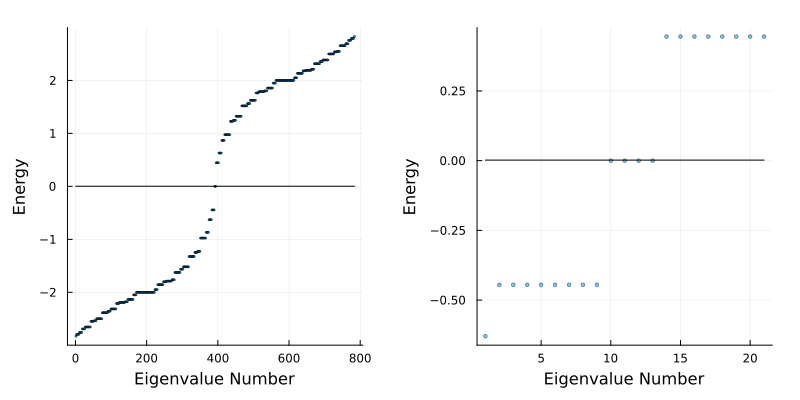

In [296]:
window = 10 # number of eigenvalues to zoom in on
mu = 0.002 # should be slightly greater than zero so all zero-energy eigenstates are included

plot1 = plot(eigenvalues,seriestype=:scatter, ms=1, ma=0.5,legend=false)
plot!(zeros(L^2) .+ mu, c=:black)
xlabel!("Eigenvalue Number")
ylabel!("Energy")

plot2 = plot(eigenvalues[Int(round(L^2/2))-window:1:Int(round(L^2/2))+window],seriestype=:scatter, ms=2, ma=0.5,legend=false)
plot!(zeros(2*window+1).+ mu, c=:black)
xlabel!("Eigenvalue Number")
ylabel!("Energy")

plot(plot1,plot2,layout=(1,2),size=(800,400),margin=5Plots.mm)

The many-body groundstate is the Slater determinant formed from all single-particle eigenstates with energy less than the chemical potential $\mu$.

In [297]:
filled_indices = findall(real(eigenvalues) .< mu);
filled_levels = eigenvectors[:,filled_indices];

### Symmetry Eigenvalues

In this section, we compute eigenvalues of the Dirac fermion under various spatial symmetry operations. We first have to find the degenerate zero-energy subspace.

In [298]:
zero_degen = length(findall(abs.(eigenvalues) .< 1e-5))
zero_eigs = eigenvectors[:,Int(round(L^2/2)-zero_degen/2+1):Int(round(L^2/2)+zero_degen/2)];

println("There are ",zero_degen," zero-energy eigenstates")

There are 4 zero-energy eigenstates


#### Rotations

We now construct the effective rotation operators in the zero-energy eigenspace:

In [299]:
C4_A_mat = zero_eigs'*C4_A*zero_eigs;
C4_B_mat = zero_eigs'*C4_B*zero_eigs;

Let's verify that they are still unitary matrices:

In [300]:
C4_A_zero_unitary = norm(C4_A_mat*C4_A_mat'-I)<1e-9
C4_B_zero_unitary = norm(C4_B_mat*C4_B_mat'-I)<1e-9

display(latexstring("C_{4,A}|_{E=0}\\;\\mathrm{unitary}?:\\;\\mathrm{$C4_A_zero_unitary}"))
display(latexstring("C_{4,B}|_{E=0}\\;\\mathrm{unitary}?:\\;\\mathrm{$C4_B_zero_unitary}"))

L"$C_{4,A}|_{E=0}\;\mathrm{unitary}?:\;\mathrm{true}$"

L"$C_{4,B}|_{E=0}\;\mathrm{unitary}?:\;\mathrm{true}$"

Diagonalizing the rotation symmetry action in the zero-energy eigenspace, we find the following eigenvalues:

In [301]:
U = eigvecs((C4_A_mat));
display(round.(diag(U'*C4_A_mat*U),digits=2))
U = eigvecs((C4_B_mat));
display(round.(diag(U'*C4_B_mat*U),digits=2))

4-element Vector{ComplexF64}:
 -1.0 - 0.0im
 -0.0 + 1.0im
 -0.0 + 1.0im
  1.0 - 0.0im

4-element Vector{ComplexF64}:
 -0.0 + 1.0im
 -0.0 - 1.0im
  1.0 + 0.0im
  1.0 + 0.0im

We know that there exists a basis in which the Dirac fermion transforms under rotations as
$$C_{M,o}: \Psi_{\vec{k}_\star} \rightarrow e^{i\frac{2\pi}{M}s_o} \Lambda(2\pi/M)
     \Psi_{\vec{k}_\star}, $$
where $\Lambda(2\pi/M) = e^{i \frac{1}{2} \frac{2\pi}{M} \sigma^z}$. We can therefore read off the value of $s_o$ for each Dirac fermion from the eigenvalues we have calculated.

#### Translations

We now construct the effective translation operators in the zero-energy eigenspace:

In [307]:
T1_mat = zero_eigs'*T1*zero_eigs;
T2_mat = zero_eigs'*T2*zero_eigs;

We will now diagonalize the rotation symmetry action in the zero-energy eigenspace. It is crucial that we choose the same basis tranformation for both symmetries because we want to be able to pair up $k_x$ with the corresponding $k_y$. We find the following eigenvalues:

In [309]:
U = eigvecs(T1_mat);

display(round.(diag(U'*T1_mat*U),digits=2))
display(round.(diag(U'*T2_mat*U),digits=2))

4-element Vector{ComplexF64}:
 -1.0 + 0.0im
 -1.0 - 0.0im
  1.0 - 0.0im
  1.0 + 0.0im

4-element Vector{ComplexF64}:
 -1.0 - 0.0im
 -1.0 - 0.0im
  1.0 - 0.0im
  1.0 + 0.0im

We know that translations act on each Dirac fermion as
$$T_{\vec{v}}:\Psi_{k_\star}\rightarrow e^{i \vec{k}_\star\cdot \vec{v}}\Psi_{\vec{k}_\star}.$$
We can therefore read off the value of $\vec{k}_\star$ for each Dirac fermion from the eigenvalues we have calculated.

## Gapped Calculations

In this section, we will find the topological invariants in the gapped phases via partial rotations.

### Parameter Input

We have two primary parameters:
- n: determines size of lattice
- tp: strength of next-nearest neighbor coupling

In [417]:
## Model Parameters ##
n = 12;
tp = 2; # gapless at 0

In [418]:
## Defining Variables ##
L = 4*n+1;
t = 1;
δ = 1;

rot_angle = pi/2
origin = [Int(L/2+1/2),Int(L/2+1/2)];

We construct the first quantized Hamiltonian $h$, defined so that
$$H=\sum_{i,j}c^\dagger_i h_{ij} c_j,$$
on a lattice with open boundary conditions.

In [419]:
h = hamiltonian_obc(L,tp,t,0);

As a consistency check, we verify that the Hamiltonian is Hermitian:

In [420]:
ishermitian(h)

true

Optionally, we can visualize the Hamiltonian:

In [421]:
viz_enabled = false # show visualization of the Hamiltonian
if viz_enabled
    visualize_obc(h,t,tp,0)
end

### Symmetries

In this section, we construct operators implementing several symmetries of $h$ and verify that they are indeed symmetries.

#### Rotation

On OBC with $L$ odd, we only have a single rotation center, which is a vertex.

We construct the unitary which implements this transformations on the first-quantized Hamiltonian:

In [422]:
rows = []
cols = []
data = Vector{Complex{Float64}}()
    
for i in 1:L
    for j in 1:L
        rot_point = rot(origin,[i,j],rot_angle)
        push!(rows, idx(rot_point[1],rot_point[2]))
        push!(cols, idx(i,j))
        if (i%2==1)&&(j%2==1)
            push!(data, 1)
        else
            push!(data, -1)
        end
    end  
end

C4 = SparseArrays.sparse(rows, cols, data, L^2, L^2);

Let's verify that $C_{4}$ is unitary:

In [423]:
println("C_4 unitary?: ",norm(C4*C4'-I)<1e-8)

C_4 unitary?: true


In [424]:
println("|[h,C_4]|: ",norm(h*C4-C4*h))

|[h,C_4]|: 0.0


#### Translation

There is no exact translation symmetry for the lattice on open boundary conditions.

### Diagonalization

In this section, we diagonalize $h$ and plot its spectrum. This time, we will see a gapped bulk spectrum, possibly with an edge mode if we are tuned to a phase with nonzero $C$.

In [425]:
@time eigenvalues, eigenvectors = eigen(Matrix(h));

  4.737129 seconds (23 allocations: 353.762 MiB, 2.23% gc time)


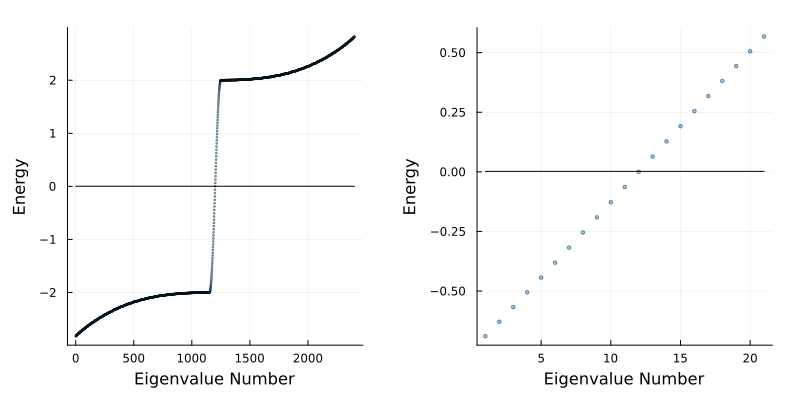

In [426]:
window = 10 # number of eigenvalues to zoom in on

plot1 = plot(eigenvalues,seriestype=:scatter, ms=1, ma=0.5,legend=false)
plot!(zeros(L^2) .+ mu, c=:black)
xlabel!("Eigenvalue Number")
ylabel!("Energy")

plot2 = plot(eigenvalues[Int(round(L^2/2))-window:1:Int(round(L^2/2))+window],seriestype=:scatter, ms=2, ma=0.5,legend=false)
plot!(zeros(2*window+1).+ mu, c=:black)
xlabel!("Eigenvalue Number")
ylabel!("Energy")

plot(plot1,plot2,layout=(1,2),size=(800,400),margin=5Plots.mm)

The many-body groundstate is the Slater determinant formed from all single-particle eigenstates with energy less than the chemical potential $\mu$.

In [427]:
mu = 0.002 # should be slightly greater than zero so all zero-energy eigenstates are included

filled_indices = findall(real(eigenvalues) .< mu);
filled_levels = eigenvectors[:,filled_indices];

### Partial Rotations

In this section, we will calculate topological invariants in the gapped phases via partial rotations. Throughout we will reference definitions and formulae from arXiv:2303.16919.

We will construct the two sets of operators $\tilde C_{4,\chi}^{+}$ and $\tilde C_{4,\chi}^{-}$. These are both symmetries of $h$, but one is order-four while the other is order-eight.

In [428]:
function C4_tilde_plus(L,R,χ)
    rows = []
    cols = []
    data = Vector{Complex{Float64}}()
    
    for i in 1:L
        for j in 1:L
            if (i>=Int(L/2+1/2)-R)&&(i<=Int(L/2+1/2)+R)&&(j>=Int(L/2+1/2)-R)&&(j<=Int(L/2+1/2)+R)
                rot_point = rot(origin,[i,j],rot_angle)
                push!(rows, idx(rot_point[1],rot_point[2]))
                push!(cols, idx(i,j))
                if (i%2==1)&&(j%2==1)
                    push!(data, 1*exp(im*χ*pi/2))
                else
                    push!(data, -1*exp(im*χ*pi/2))
                end
            else
                push!(rows, idx(i,j)); push!(cols, idx(i,j)); push!(data,1);
            end
        end  
    end
    
    M = SparseArrays.sparse(rows, cols, data, L^2, L^2)

    return M
end;

function C4_tilde_minus(L,R,χ)
    rows = []
    cols = []
    data = Vector{Complex{Float64}}()
    
    for i in 1:L
        for j in 1:L
            if (i>=Int(L/2+1/2)-R)&&(i<=Int(L/2+1/2)+R)&&(j>=Int(L/2+1/2)-R)&&(j<=Int(L/2+1/2)+R)
                rot_point = rot(origin,[i,j],rot_angle)
                push!(rows, idx(rot_point[1],rot_point[2]))
                push!(cols, idx(i,j))
                if (i%2==1)&&(j%2==1)
                    push!(data, 1*exp(im*χ*pi/2)*exp(im*pi/4))
                else
                    push!(data, -1*exp(im*χ*pi/2)*exp(im*pi/4))
                end
            else
                push!(rows, idx(i,j)); push!(cols, idx(i,j)); push!(data,1);
            end
        end  
    end
    
    M = SparseArrays.sparse(rows, cols, data, L^2, L^2)

    return M
end;

These operators should be symmetries which satisfy $(\tilde C_{4,\chi}^{+})=+I$ and $(\tilde C_{4,\chi}^{-})^4=(-1)^{F}$, which we verify:

In [429]:
M = C4_tilde_plus(L,L/2,0)
display(L"(C^+_4)^4=I?:")
println(norm(M*M*M*M - I)<1e-8)
display(L"[C^+_4,h]:")
println(norm(M*h-h*M))

M = C4_tilde_minus(L,L/2,0)
display(L"(C^-_4)^4=-I?:")
println(norm(M*M*M*M + I)<1e-8)
display(L"[C^-_4,h]:")
println(norm(M*h-h*M))

L"$(C^+_4)^4=I?:$"

true


L"$[C^+_4,h]:$"

0.0


L"$(C^-_4)^4=-I?:$"

true


L"$[C^-_4,h]:$"

0.0


We now want to restrict $C_{4,\chi}^\pm$ to a rotationally invariant set of sites $D$, which we denote $C_{4,\chi}^\pm|_D$. We want to choose the radius $R$ to be sufficiently large so that we capture the bulk behavior, without making it so large that the edge influences the result.

We can then extract universal information via the formula:
\begin{equation*}
   \bra{\Psi}C_{M,o,\chi}^{\pm}|_D\ket{\Psi}=e^{\frac{2\pi i}{M}l_{D,o,\chi}^{\pm}-\gamma_{D,o,\chi}^{\pm}},
\end{equation*}
where $\gamma_{D,o,\chi}^{\pm}\propto \partial D$ sets the real-valued amplitude and $l_{D,o,\chi}^{\pm}$ encodes the topological data. In particular, $l_{D,o,\chi}^{\pm}$ satisfies
\begin{equation}
    l_{D,o,\chi}^{\pm}= \frac{C \chi^2}{2} + \mathcal{S}_o^{\pm}\chi + K_o^{\pm}\text{ mod }M.
\end{equation}

In [461]:
χ_list = 0:3
C_tilde_plus_list = []
C_tilde_minus_list = []
l_plus_list = []
l_minus_list = []

R = 18 # partial rotation region, large but not entire system

filled_indices = findall(real(eigenvalues) .< mu);
filled_levels = eigenvectors[:,filled_indices];

for χ in χ_list
    # Construct the rotation operator
    C_tilde_plus_chi_D = C4_tilde_plus(L,R,χ)
    C_tilde_minus_chi_D = C4_tilde_minus(L,R,χ)
    
    # Find expectation value
    expect_C_tilde_plus_chi_D = det(filled_levels' * C_tilde_plus_chi_D * filled_levels)
    expect_C_tilde_minus_chi_D = det(filled_levels' * C_tilde_minus_chi_D * filled_levels)
    
    l_plus = 2*angle(expect_C_tilde_plus_chi_D)/pi
    l_minus = 2*angle(expect_C_tilde_minus_chi_D)/pi
    
    push!(C_tilde_plus_list,expect_C_tilde_plus_chi_D)
    push!(C_tilde_minus_list,expect_C_tilde_minus_chi_D)
    push!(l_plus_list,l_plus)
    push!(l_minus_list,l_minus)
end

In [462]:
Theta_plus = mod(l_plus_list[1],2)
Theta_minus = mod(l_minus_list[1],4)
S = mod((2*(Theta_minus-Theta_plus)),4)

display(latexstring("\\Theta^+:\\;$Theta_plus"))
display(latexstring("\\Theta^-:\\;$Theta_minus"))
display(latexstring("\\mathcal{S}:\\;$S"))

L"$\Theta^+:\;0.49999999998315103$"

L"$\Theta^-:\;0.7499997018115786$"

L"$\mathcal{S}:\;0.49999940365685513$"

$\Theta^+$ should be a multiple of $\frac{1}{2}$, and $\Theta^-$ should be a multiple of $\frac{1}{4}$.

#### Fitting to the $l$ vs $\chi$ curve

Let's fit a quadratic polynomial mod 4 to the $\langle \Psi|\tilde C^+_{4,\chi}|\Psi\rangle$ vs. $\chi$ data. We tune by hand $C$, $\mathcal{S}^+$, and $K^+$ to fit the data.

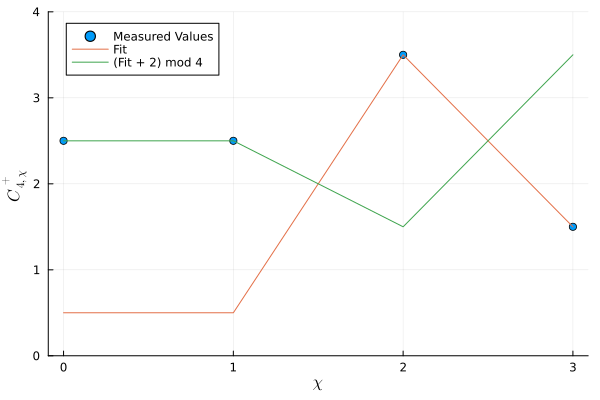

In [463]:
C = -1
S_plus = S 
K_plus = 0.5

scatter(χ_list,mod.(l_plus_list,4),ylims=(0,4),label="Measured Values")
plot!(χ_list,mod.((C/2)*(χ_list.^2) .+ S_plus*χ_list .+ K_plus,4),label="Fit")
plot!(χ_list,mod.((C/2)*(χ_list.^2) .+ S_plus*χ_list .+ K_plus .+ 2,4),label="(Fit + 2) mod 4")

xlabel!(L"\chi")
ylabel!(L"C_{4,\chi}^+")

Now, let's fit a quadratic polynomial mod 4 to the $\langle \Psi|\tilde C^-_{4,\chi}|\Psi\rangle$ vs. $\chi$ data:

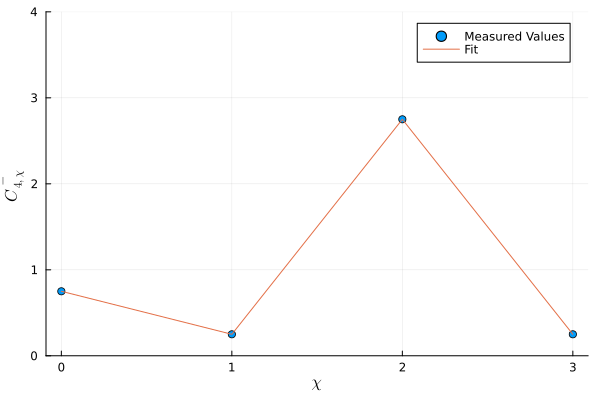

In [464]:
S_minus = 0
K_minus = 0.75

scatter(χ_list,mod.(l_minus_list,4),ylims=(0,4),label="Measured Values")
plot!(χ_list,mod.((C/2)*χ_list.^2+S_minus*χ_list.+K_minus,4),label="Fit")
xlabel!(L"\chi")
ylabel!(L"C_{4,\chi}^-")

Now that we have $K^+$ and $K^-$, we can find $\Theta^+:=K^+ \text{ mod }2$ and $\Theta^-:=K^- \text{ mod }4$ and use 
$$2(\Theta^--\Theta^+)=\mathcal{S}^+\text{ mod }4$$
to extract the discrete shift $\mathcal{S}$ and the $M=4$ relation
$$\ell=\frac{5}{4}C+2\Theta_o^+\text{ mod }4,\text{ }$$
to extract $\ell$.

In [466]:
Theta_plus = mod(K_plus,2)
Theta_minus = mod(K_minus,4)
S = mod((2*(Theta_minus-Theta_plus)),4)

l = mod((5/4)*C + 2*Theta_plus,4)

display(latexstring("C:\\;$C\\qquad \\mathcal{S}:\\;$S\\qquad \\ell:\\;$l\\qquad \\Theta^+:\\;$Theta_plus\\qquad\\Theta^-:\\;$Theta_minus"))

L"$C:\;-1\qquad \mathcal{S}:\;0.5\qquad \ell:\;3.75\qquad \Theta^+:\;0.5\qquad\Theta^-:\;0.75$"

# Defect Hamiltonians

In this section, we present the code for measuring the current and energy density on a lattice with various crystalline defects.

## Disclinations

### Parameter Input

In [665]:
## PARAMETERS ##
n = 12; # tunes the size of the lattice
tp = 0; # only critical point is at 0
mu = 0.002;
disc_type = "A"; # "A" or "B"
################

In [666]:
## Defining Variables ##
L = 4*n + 1
t = 1;

Lx = Int(L/2-0.5)
Ly = Int(L/2+0.5);

L_tot = 3*Lx*Ly+1

rot_angle = pi/2
origin = [Int(round(L/2))+1,Int(round(L/2))+1];

In [667]:
if disc_type == "A"
    h = disc_hamiltonian_A(L,tp,t,pi/4);
elseif disc_type == "B";
    h = disc_hamiltonian_B(L,tp,t,pi/4);
end;

In [668]:
ishermitian(h)

true

In [669]:
viz_enabled = false;
if viz_enabled
    visualize_disc(h, tp, t, pi/4)
end

### Generating Data

Here, we calculate the current and energy density in a wedge of the lattice with disclination.

In [670]:
total_big_data = []; v1_big_data = []; v2_big_data = [];
total_H_big_data = []; v1_H_big_data = []; v2_H_big_data = [];

counter = 0

δϕs = 0:0.2:2*pi
@showprogress for δϕ in δϕs
    if tp != 0
        error("ERROR: Not tuned to the critical point. Ensure that tp=0 for this calculation.")
    end
    ## Create Sparse Matrix ##
    if disc_type == "A"
        H_disc = disc_hamiltonian_A(L, tp, t, δϕ+pi/2) + 1e-8*Hermitian(rand(3*Lx*Ly+1,3*Lx*Ly+1)+im*rand(3*Lx*Ly+1,3*Lx*Ly+1));
        # δϕ shifted to match rotation phase
        start = 1
    elseif disc_type == "B"
        H_disc = disc_hamiltonian_B(L, tp, t, δϕ) + 1e-8*Hermitian(rand(3*Lx*Ly+1,3*Lx*Ly+1)+im*rand(3*Lx*Ly+1,3*Lx*Ly+1));
        start = 2
    end

    tot_eigenvalues, tot_eigenvectors = eigen(Matrix(H_disc))

    filled_indices = findall(real(tot_eigenvalues) .< mu);
    filled_levels = tot_eigenvectors[:,filled_indices];

    ## Current ##
    
    A_vecs_1 = Vector{Vector{ComplexF64}}()
    B_vecs_1 = Vector{Vector{ComplexF64}}()
    C_vecs_1 = Vector{Vector{ComplexF64}}()
    D_vecs_1 = Vector{Vector{ComplexF64}}()

    global x_distance_1 = []
    global y_distance_1 = []
    
    sin_1 = []
    cos_1 = []

    global i_1 = []
    global j_1 = []
    for i in 1:2:Int(L/2-1/2)-1
        for j in start:2:Int(L/2-1/2)-1
            push!(A_vecs_1,filled_levels[disc_idx(i,j,1),:])
            push!(B_vecs_1,filled_levels[disc_idx(i+1,j,1),:])
            push!(C_vecs_1,filled_levels[disc_idx(i+1,j+1,1),:])
            push!(D_vecs_1,filled_levels[disc_idx(i,j+1,1),:])
            
            x = -(Int(L/2-1/2)+1-i)
            y = j-1
            
            push!(x_distance_1,x)
            push!(y_distance_1,y)
            
            push!(cos_1,x/(x^2+y^2))
            push!(sin_1,y/(x^2+y^2))

            push!(i_1,i)
            push!(j_1,j)
        end
    end

    ##############

    A_vecs_3 = Vector{Vector{ComplexF64}}()
    B_vecs_3 = Vector{Vector{ComplexF64}}()
    C_vecs_3 = Vector{Vector{ComplexF64}}()
    D_vecs_3 = Vector{Vector{ComplexF64}}()

    x_distance_3 = []
    y_distance_3 = []
    
    sin_3 = []
    cos_3 = []

    global i_3 = []
    global j_3 = []
    for i in 3:2:Int(L/2-1/2)-1
        for j in 1:2:Int(L/2-1/2)-1
            push!(A_vecs_3,filled_levels[disc_idx(i,j,3),:])
            push!(B_vecs_3,filled_levels[disc_idx(i,j+1,3),:])
            push!(C_vecs_3,filled_levels[disc_idx(i-1,j+1,3),:])
            push!(D_vecs_3,filled_levels[disc_idx(i-1,j,3),:])
            
            x = j-1
            y = Int(L/2-1/2)+1-i

            push!(x_distance_3,x)
            push!(y_distance_3,y)
            
            push!(cos_3,x/(x^2+y^2))
            push!(sin_3,y/(x^2+y^2))

            push!(i_3,i)
            push!(j_3,j)
        end
    end

    A_mat_1 = reduce(hcat,A_vecs_1);
    B_mat_1 = reduce(hcat,B_vecs_1);
    C_mat_1 = reduce(hcat,C_vecs_1);
    D_mat_1 = reduce(hcat,D_vecs_1);

    A_mat_3 = reduce(hcat,A_vecs_3);
    B_mat_3 = reduce(hcat,B_vecs_3);
    C_mat_3 = reduce(hcat,C_vecs_3);
    D_mat_3 = reduce(hcat,D_vecs_3);

    cAA_1 = sum(A_mat_1 .* conj(A_mat_1),dims=1);
    cBB_1 = sum(B_mat_1 .* conj(B_mat_1),dims=1);
    cCC_1 = sum(C_mat_1 .* conj(C_mat_1),dims=1);
    cDD_1 = sum(D_mat_1 .* conj(D_mat_1),dims=1);
    cAB_1 = sum(A_mat_1 .* conj(B_mat_1),dims=1);
    cBA_1 = sum(B_mat_1 .* conj(A_mat_1),dims=1);
    cAC_1 = sum(A_mat_1 .* conj(C_mat_1),dims=1);
    cCA_1 = sum(C_mat_1 .* conj(A_mat_1),dims=1);
    cAD_1 = sum(A_mat_1 .* conj(D_mat_1),dims=1);
    cDA_1 = sum(D_mat_1 .* conj(A_mat_1),dims=1);
    cBC_1 = sum(B_mat_1 .* conj(C_mat_1),dims=1);
    cCB_1 = sum(C_mat_1 .* conj(B_mat_1),dims=1);
    cBD_1 = sum(B_mat_1 .* conj(D_mat_1),dims=1);
    cDB_1 = sum(D_mat_1 .* conj(B_mat_1),dims=1);
    cCD_1 = sum(C_mat_1 .* conj(D_mat_1),dims=1);
    cDC_1 = sum(D_mat_1 .* conj(C_mat_1),dims=1);

    cAA_3 = sum(A_mat_3 .* conj(A_mat_3),dims=1);
    cBB_3 = sum(B_mat_3 .* conj(B_mat_3),dims=1);
    cCC_3 = sum(C_mat_3 .* conj(C_mat_3),dims=1);
    cDD_3 = sum(D_mat_3 .* conj(D_mat_3),dims=1);
    cAB_3 = sum(A_mat_3 .* conj(B_mat_3),dims=1);
    cBA_3 = sum(B_mat_3 .* conj(A_mat_3),dims=1);
    cAC_3 = sum(A_mat_3 .* conj(C_mat_3),dims=1);
    cCA_3 = sum(C_mat_3 .* conj(A_mat_3),dims=1);
    cAD_3 = sum(A_mat_3 .* conj(D_mat_3),dims=1);
    cDA_3 = sum(D_mat_3 .* conj(A_mat_3),dims=1);
    cBC_3 = sum(B_mat_3 .* conj(C_mat_3),dims=1);
    cCB_3 = sum(C_mat_3 .* conj(B_mat_3),dims=1);
    cBD_3 = sum(B_mat_3 .* conj(D_mat_3),dims=1);
    cDB_3 = sum(D_mat_3 .* conj(B_mat_3),dims=1);
    cCD_3 = sum(C_mat_3 .* conj(D_mat_3),dims=1);
    cDC_3 = sum(D_mat_3 .* conj(C_mat_3),dims=1);

    ψ11t_1 = vec(cBB_1-im*cBD_1+im*cDB_1+cDD_1)
    ψ22t_1 = vec(cAA_1-im*cAC_1+im*cCA_1+cCC_1)
    ψ21t_1 = vec(cAB_1-im*cAD_1+im*cCB_1+cCD_1)
    ψ12t_1 = vec(cBA_1-im*cBC_1+im*cDA_1+cDC_1)

    ψ11b_1 = vec(cAA_1+im*cAC_1-im*cCA_1+cCC_1)
    ψ22b_1 = vec(cBB_1+im*cBD_1-im*cDB_1+cDD_1)
    ψ21b_1 = vec(-cBA_1-im*cBC_1+im*cDA_1-cDC_1)
    ψ12b_1 = vec(-cAB_1-im*cAD_1+im*cCB_1-cCD_1)

    jt_v1_1 = ψ11t_1+ψ22t_1
    jt_v2_1 = ψ11b_1+ψ22b_1

    jr_v1_1 = -cos_1.*(im*ψ21t_1-im*ψ12t_1)+sin_1.*(ψ21t_1+ψ12t_1)
    jr_v2_1 = -cos_1.*(im*ψ21b_1-im*ψ12b_1)+sin_1.*(ψ21b_1+ψ12b_1)

    jθ_v1_1 = y_distance_1.*(im*ψ21t_1-im*ψ12t_1)+x_distance_1.*(ψ21t_1+ψ12t_1)
    jθ_v2_1 = y_distance_1.*(im*ψ21b_1-im*ψ12b_1)+x_distance_1.*(ψ21b_1+ψ12b_1);

    ψ11t_3 = vec(cBB_3-im*cBD_3+im*cDB_3+cDD_3)
    ψ22t_3 = vec(cAA_3-im*cAC_3+im*cCA_3+cCC_3)
    ψ21t_3 = vec(cAB_3-im*cAD_3+im*cCB_3+cCD_3)
    ψ12t_3 = vec(cBA_3-im*cBC_3+im*cDA_3+cDC_3)

    ψ11b_3 = vec(cAA_3+im*cAC_3-im*cCA_3+cCC_3)
    ψ22b_3 = vec(cBB_3+im*cBD_3-im*cDB_3+cDD_3)
    ψ21b_3 = vec(-cBA_3-im*cBC_3+im*cDA_3-cDC_3)
    ψ12b_3 = vec(-cAB_3-im*cAD_3+im*cCB_3-cCD_3)

    jt_v1_3 = ψ11t_3+ψ22t_3
    jt_v2_3 = ψ11b_3+ψ22b_3

    jr_v1_3 = -cos_3.*(im*ψ21t_3-im*ψ12t_3)+sin_3.*(ψ21t_3+ψ12t_3)
    jr_v2_3 = -cos_3.*(im*ψ21b_3-im*ψ12b_3)+sin_3.*(ψ21b_3+ψ12b_3)

    jθ_v1_3 = y_distance_3.*(im*ψ21t_3-im*ψ12t_3)+x_distance_3.*(ψ21t_3+ψ12t_3)
    jθ_v2_3 = y_distance_3.*(im*ψ21b_3-im*ψ12b_3)+x_distance_3.*(ψ21b_3+ψ12b_3);
    
    ####### TOTAL CURRENT #######
    v1 = 1
    v2 = 1
    
    ## Section 1 ##
    if δϕ==0
        jt_clean_1 = v1*jt_v1_1 + v2*jt_v2_1
        jt_1 = v1*jt_v1_1 + v2*jt_v2_1

        jr_clean_1 = v1*jr_v1_1 + v2*jr_v2_1
        jr_1 = v1*jr_v1_1 + v2*jr_v2_1

        jθ_clean_1 = v1*jθ_v1_1 + v2*jθ_v2_1
        jθ_1 = v1*jθ_v1_1 + v2*jθ_v2_1
    else
        jt_1 = v1*jt_v1_1 + v2*jt_v2_1
        jr_1 = v1*jr_v1_1 + v2*jr_v2_1
        jθ_1 = v1*jθ_v1_1 + v2*jθ_v2_1
    end;

    ## Section 3 ##
    if δϕ==0
        jt_clean_3 = v1*jt_v1_3 + v2*jt_v2_3
        jt_3 = v1*jt_v1_3 + v2*jt_v2_3

        jr_clean_3 = v1*jr_v1_3 + v2*jr_v2_3
        jr_3 = v1*jr_v1_3 + v2*jr_v2_3

        jθ_clean_3 = v1*jθ_v1_3 + v2*jθ_v2_3
        jθ_3 = v1*jθ_v1_3 + v2*jθ_v2_3
    else
        jt_3 = v1*jt_v1_3 + v2*jt_v2_3
        jr_3 = v1*jr_v1_3 + v2*jr_v2_3
        jθ_3 = v1*jθ_v1_3 + v2*jθ_v2_3
    end;
    
    jθ_total = copy(jθ_1)
            
    ####### VALLEY 1 CURRENT #######
    v1 = 1
    v2 = 0
    
    ## Section 1 ##
    if δϕ==0
        jt_clean_1 = v1*jt_v1_1 + v2*jt_v2_1
        jt_1 = v1*jt_v1_1 + v2*jt_v2_1

        jr_clean_1 = v1*jr_v1_1 + v2*jr_v2_1
        jr_1 = v1*jr_v1_1 + v2*jr_v2_1

        jθ_clean_1 = v1*jθ_v1_1 + v2*jθ_v2_1
        jθ_1 = v1*jθ_v1_1 + v2*jθ_v2_1
    else
        jt_1 = v1*jt_v1_1 + v2*jt_v2_1
        jr_1 = v1*jr_v1_1 + v2*jr_v2_1
        jθ_1 = v1*jθ_v1_1 + v2*jθ_v2_1
    end;

    ## Section 3 ##
    if δϕ==0
        jt_clean_3 = v1*jt_v1_3 + v2*jt_v2_3
        jt_3 = v1*jt_v1_3 + v2*jt_v2_3

        jr_clean_3 = v1*jr_v1_3 + v2*jr_v2_3
        jr_3 = v1*jr_v1_3 + v2*jr_v2_3

        jθ_clean_3 = v1*jθ_v1_3 + v2*jθ_v2_3
        jθ_3 = v1*jθ_v1_3 + v2*jθ_v2_3
    else
        jt_3 = v1*jt_v1_3 + v2*jt_v2_3
        jr_3 = v1*jr_v1_3 + v2*jr_v2_3
        jθ_3 = v1*jθ_v1_3 + v2*jθ_v2_3
    end;
    
    jθ_v1 = copy(jθ_1)
    
    
    ####### VALLEY 2 CURRENT #######
    v1 = 0
    v2 = 1
    
    ## Section 1 ##
    if δϕ==0
        jt_clean_1 = v1*jt_v1_1 + v2*jt_v2_1
        jt_1 = v1*jt_v1_1 + v2*jt_v2_1

        jr_clean_1 = v1*jr_v1_1 + v2*jr_v2_1
        jr_1 = v1*jr_v1_1 + v2*jr_v2_1

        jθ_clean_1 = v1*jθ_v1_1 + v2*jθ_v2_1
        jθ_1 = v1*jθ_v1_1 + v2*jθ_v2_1
    else
        jt_1 = v1*jt_v1_1 + v2*jt_v2_1
        jr_1 = v1*jr_v1_1 + v2*jr_v2_1
        jθ_1 = v1*jθ_v1_1 + v2*jθ_v2_1
    end;

    ## Section 3 ##
    if δϕ==0
        jt_clean_3 = v1*jt_v1_3 + v2*jt_v2_3
        jt_3 = v1*jt_v1_3 + v2*jt_v2_3

        jr_clean_3 = v1*jr_v1_3 + v2*jr_v2_3
        jr_3 = v1*jr_v1_3 + v2*jr_v2_3

        jθ_clean_3 = v1*jθ_v1_3 + v2*jθ_v2_3
        jθ_3 = v1*jθ_v1_3 + v2*jθ_v2_3
    else
        jt_3 = v1*jt_v1_3 + v2*jt_v2_3
        jr_3 = v1*jr_v1_3 + v2*jr_v2_3
        jθ_3 = v1*jθ_v1_3 + v2*jθ_v2_3
    end;
    
    jθ_v2 = copy(jθ_1)
        
    pt = 5*n + 1

    if counter == 0
        xs = []
        ys = []
        vals = []
        for k in 1:length(jθ_1)
            i = i_1[k]
            j = j_1[k]
            index = disc_idx(i,j,1)
            x, y = idx_to_2d(index)
            val = jθ_1[k]
            push!(xs,x)
            push!(ys,y)  
            if k == pt
                push!(vals,-1)
            else
                push!(vals,real(val))
            end
        end

        for k in 1:length(jθ_3)
            i = i_3[k]
            j = j_3[k]
            index = disc_idx(i,j,3)
            x, y = idx_to_2d(index)
            val = jθ_3[k]
            push!(xs,x)
            push!(ys,y)
            push!(vals,real(val))
        end

        s = scatter(xs, ys, zcolor=vals, marker=:circle, clim=(-.1,.1), cmap=cgrad([:black,:red,:yellow,:white]), markersize=4,legend=true,size=((600,600)), markerstrokewidth=0)
        # display(s)
    end
    
    counter += 1
    
    push!(total_big_data,real(jθ_total))
    push!(v1_big_data,real(jθ_v1))
    push!(v2_big_data,real(jθ_v2))
    
    s1 = scatter(δϕs[1:counter],reduce(hcat,total_big_data)[pt,:])
    s2 = scatter(δϕs[1:counter],reduce(hcat,v1_big_data)[pt,:])
    s3 = scatter(δϕs[1:counter],reduce(hcat,v2_big_data)[pt,:])
    
    s = plot(s1,s2,s3,layout=(1,3),size=(1400,400))
    # display(s)
    
    ## Energy Density ##
    
    A_vecs_1 = Vector{Vector{ComplexF64}}()
    B_vecs_1 = Vector{Vector{ComplexF64}}()
    C_vecs_1 = Vector{Vector{ComplexF64}}()
    D_vecs_1 = Vector{Vector{ComplexF64}}()

    A_dot_vecs_1 = Vector{Vector{ComplexF64}}()
    B_dot_vecs_1 = Vector{Vector{ComplexF64}}()
    C_dot_vecs_1 = Vector{Vector{ComplexF64}}()
    D_dot_vecs_1 = Vector{Vector{ComplexF64}}()

    global H_x_distance_1 = []
    global H_y_distance_1 = []

    global H_i_1 = []
    global H_j_1 = []
    for i in 3:2:Int(L/2-1/2)-2
        for j in start+2:2:Int(L/2-1/2)-2
            push!(A_vecs_1,filled_levels[disc_idx(i,j,1),:])
            push!(B_vecs_1,filled_levels[disc_idx(i+1,j,1),:])
            push!(C_vecs_1,filled_levels[disc_idx(i+1,j+1,1),:])
            push!(D_vecs_1,filled_levels[disc_idx(i,j+1,1),:])

            push!(A_dot_vecs_1,(H_disc[disc_idx(i,j,1),disc_idx(i,j,1)]'*filled_levels[disc_idx(i,j,1),:] + H_disc[disc_idx(i+1,j,1),disc_idx(i,j,1)]'*filled_levels[disc_idx(i+1,j,1),:] + H_disc[disc_idx(i-1,j,1),disc_idx(i,j,1)]'*filled_levels[disc_idx(i-1,j,1),:] + H_disc[disc_idx(i,j+1,1),disc_idx(i,j,1)]'*filled_levels[disc_idx(i,j+1,1),:] + H_disc[disc_idx(i,j-1,1),disc_idx(i,j,1)]'*filled_levels[disc_idx(i,j-1,1),:]))
            push!(B_dot_vecs_1,(H_disc[disc_idx(i+1,j,1),disc_idx(i+1,j,1)]'*filled_levels[disc_idx(i+1,j,1),:] + H_disc[disc_idx(i+2,j,1),disc_idx(i+1,j,1)]'*filled_levels[disc_idx(i+2,j,1),:] + H_disc[disc_idx(i,j,1),disc_idx(i+1,j,1)]'*filled_levels[disc_idx(i,j,1),:] + H_disc[disc_idx(i+1,j+1,1),disc_idx(i+1,j,1)]'*filled_levels[disc_idx(i+1,j+1,1),:] + H_disc[disc_idx(i+1,j-1,1),disc_idx(i+1,j,1)]'*filled_levels[disc_idx(i+1,j-1,1),:]))
            push!(C_dot_vecs_1,(H_disc[disc_idx(i+1,j+1,1),disc_idx(i+1,j+1,1)]'*filled_levels[disc_idx(i+1,j+1,1),:] + H_disc[disc_idx(i+2,j+1,1),disc_idx(i+1,j+1,1)]'*filled_levels[disc_idx(i+2,j+1,1),:] + H_disc[disc_idx(i,j+1,1),disc_idx(i+1,j+1,1)]'*filled_levels[disc_idx(i,j+1,1),:] + H_disc[disc_idx(i+1,j+2,1),disc_idx(i+1,j+1,1)]'*filled_levels[disc_idx(i+1,j+2,1),:] + H_disc[disc_idx(i+1,j,1),disc_idx(i+1,j+1,1)]'*filled_levels[disc_idx(i+1,j,1),:]))
            push!(D_dot_vecs_1,(H_disc[disc_idx(i,j+1,1),disc_idx(i,j+1,1)]'*filled_levels[disc_idx(i,j+1,1),:] + H_disc[disc_idx(i+1,j+1,1),disc_idx(i,j+1,1)]'*filled_levels[disc_idx(i+1,j+1,1),:] + H_disc[disc_idx(i-1,j+1,1),disc_idx(i,j+1,1)]'*filled_levels[disc_idx(i-1,j+1,1),:] + H_disc[disc_idx(i,j+2,1),disc_idx(i,j+1,1)]'*filled_levels[disc_idx(i,j+2,1),:] + H_disc[disc_idx(i,j,1),disc_idx(i,j+1,1)]'*filled_levels[disc_idx(i,j,1),:]))

            push!(H_x_distance_1,-(Int(L/2-1/2)+1-i))
            push!(H_y_distance_1,j-1)

            push!(H_i_1,i)
            push!(H_j_1,j)
        end
    end

    A_mat_1 = reduce(hcat,A_vecs_1);
    B_mat_1 = reduce(hcat,B_vecs_1);
    C_mat_1 = reduce(hcat,C_vecs_1);
    D_mat_1 = reduce(hcat,D_vecs_1);

    A_dot_mat_1 = reduce(hcat,A_dot_vecs_1);
    B_dot_mat_1 = reduce(hcat,B_dot_vecs_1);
    C_dot_mat_1 = reduce(hcat,C_dot_vecs_1);
    D_dot_mat_1 = reduce(hcat,D_dot_vecs_1);

    cAA_1 = sum(A_mat_1 .* conj(A_dot_mat_1),dims=1);
    cBB_1 = sum(B_mat_1 .* conj(B_dot_mat_1),dims=1);
    cCC_1 = sum(C_mat_1 .* conj(C_dot_mat_1),dims=1);
    cDD_1 = sum(D_mat_1 .* conj(D_dot_mat_1),dims=1);
    cAB_1 = sum(A_mat_1 .* conj(B_dot_mat_1),dims=1);
    cBA_1 = sum(B_mat_1 .* conj(A_dot_mat_1),dims=1);
    cAC_1 = sum(A_mat_1 .* conj(C_dot_mat_1),dims=1);
    cCA_1 = sum(C_mat_1 .* conj(A_dot_mat_1),dims=1);
    cAD_1 = sum(A_mat_1 .* conj(D_dot_mat_1),dims=1);
    cDA_1 = sum(D_mat_1 .* conj(A_dot_mat_1),dims=1);
    cBC_1 = sum(B_mat_1 .* conj(C_dot_mat_1),dims=1);
    cCB_1 = sum(C_mat_1 .* conj(B_dot_mat_1),dims=1);
    cBD_1 = sum(B_mat_1 .* conj(D_dot_mat_1),dims=1);
    cDB_1 = sum(D_mat_1 .* conj(B_dot_mat_1),dims=1);
    cCD_1 = sum(C_mat_1 .* conj(D_dot_mat_1),dims=1);
    cDC_1 = sum(D_mat_1 .* conj(C_dot_mat_1),dims=1);
    
    global ψ11t_1 = vec(cBB_1-im*cBD_1+im*cDB_1+cDD_1)
    global ψ22t_1 = vec(cAA_1-im*cAC_1+im*cCA_1+cCC_1)
    ψ21t_1 = vec(cAB_1-im*cAD_1+im*cCB_1+cCD_1)
    ψ12t_1 = vec(cBA_1-im*cBC_1+im*cDA_1+cDC_1)

    global ψ11b_1 = vec(cAA_1+im*cAC_1-im*cCA_1+cCC_1)
    global ψ22b_1 = vec(cBB_1+im*cBD_1-im*cDB_1+cDD_1)
    ψ21b_1 = vec(-cBA_1-im*cBC_1+im*cDA_1-cDC_1)
    ψ12b_1 = vec(-cAB_1-im*cAD_1+im*cCB_1-cCD_1)

    E_v1_1 = ψ11t_1+ψ22t_1
    E_v2_1 = ψ11b_1+ψ22b_1
    
    push!(total_H_big_data,real(E_v1_1.+E_v2_1))
    push!(v1_H_big_data,real(E_v1_1))
    push!(v2_H_big_data,real(E_v2_1))
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:51


In [671]:
total_big_data_mat = reduce(hcat,total_big_data);
v1_big_data_mat = reduce(hcat,v1_big_data);
v2_big_data_mat = reduce(hcat,v2_big_data);

total_H_big_data_mat = reduce(hcat,total_H_big_data);
v1_H_big_data_mat = reduce(hcat,v1_H_big_data);
v2_H_big_data_mat = reduce(hcat,v2_H_big_data);

### Choosing sites to plot

In this section, we extract indices which are in the bulk of the lattice, neither too close to the defect core nor the edge, to include in our final plot.

In [672]:
## PARAMETERS ##
x_min_scale = 0.26; x_max_scale = 0.47; # in [0,0.5]
y_min_scale = -0.47; y_max_scale = -0.26; # in [-0.5,0.0]
################

if (x_min_scale >= x_max_scale)|(y_min_scale >= y_max_scale)
    error("ERROR: Invalid bounds")
end

meas_indices = [];

for i in 1:size(v1_big_data_mat)[1]
    x = x_distance_1[i]; y = y_distance_1[i];
    x_max = maximum(x_distance_1); x_min = minimum(x_distance_1); x_range = x_max - x_min;
    y_max = maximum(y_distance_1); y_min = minimum(y_distance_1); y_range = y_max - y_min;    

    if (x>x_min+x_range/2+x_min_scale*x_range)&&(x<x_min+x_range/2+x_max_scale*x_range)&&(y>y_min+y_range/2+y_min_scale*y_range)&&(y<y_min+y_range/2+y_max_scale*y_range)
        push!(meas_indices,i)
    end
end

H_meas_indices = [];

for i in 1:size(v1_H_big_data_mat)[1]
    x = H_x_distance_1[i]; y = H_y_distance_1[i];
    x_max = maximum(H_x_distance_1); x_min = minimum(H_x_distance_1); x_range = x_max - x_min;
    y_max = maximum(H_y_distance_1); y_min = minimum(H_y_distance_1); y_range = y_max - y_min;    

    if (x>x_min+x_range/2+x_min_scale*x_range)&&(x<x_min+x_range/2+x_max_scale*x_range)&&(y>y_min+y_range/2+y_min_scale*y_range)&&(y<y_min+y_range/2+y_max_scale*y_range)
        push!(H_meas_indices,i)
    end
end

if (length(meas_indices)== 0)|(length(H_meas_indices) == 0) 
    error("ERROR: No sites in specified range. Increase system size or range cutoff.")
else 
    n_sites = length(meas_indices)
    println("There are $n_sites sites in the specified range")
end

There are 4 sites in the specified range


### Finding zeros and extrema

We now find the zero crossings of the current and the minima and maxima of the energy density as a function of applied flux $\delta\alpha$. 

In [673]:
v1_intercept_list = []
for ind in meas_indices
    xs = δϕs
    ys = v1_big_data_mat[ind,:]

    old_sign = ys[end]/abs(ys[end])
    for i in 1:length(ys)
        new_sign = ys[i]/abs(ys[i])
        if old_sign < 0 && new_sign > 0
            global flip = i
        end
        old_sign = copy(new_sign)
    end

    m = (ys[flip]-ys[flip-1])/(xs[flip]-xs[flip-1])
    b = ys[flip-1]

    Δx = -ys[flip-1]/m

    x_intercept = xs[flip-1]+Δx

    push!(v1_intercept_list,x_intercept)
end
println(circular_mean(v1_intercept_list))

v2_intercept_list = []
for ind in meas_indices
    xs = δϕs
    ys = v2_big_data_mat[ind,:]

    old_sign = ys[end]/abs(ys[end])
    for i in 1:length(ys)
        new_sign = ys[i]/abs(ys[i])
        if old_sign < 0 && new_sign > 0
            global flip = i
        end
        old_sign = copy(new_sign)
    end

    m = (ys[flip]-ys[flip-1])/(xs[flip]-xs[flip-1])
    b = ys[flip-1]

    Δx = -ys[flip-1]/m

    x_intercept = xs[flip-1]+Δx

    push!(v2_intercept_list,x_intercept)
end
print(circular_mean(v2_intercept_list))

1.4215485170800344
1.7201490839120965

In [674]:
v1_other_intercept_list = []
for ind in meas_indices
    xs = δϕs
    ys = v1_big_data_mat[ind,:]

    old_sign = ys[end]/abs(ys[end])
    for i in 1:length(ys)
        new_sign = ys[i]/abs(ys[i])
        if old_sign > 0 && new_sign < 0
            global flip = i
        end
        old_sign = copy(new_sign)
    end

    m = (ys[flip]-ys[flip-1])/(xs[flip]-xs[flip-1])
    b = ys[flip-1]

    Δx = -ys[flip-1]/m

    x_intercept = xs[flip-1]+Δx

    push!(v1_other_intercept_list,x_intercept)
end
println(circular_mean(v1_other_intercept_list))

v2_other_intercept_list = []
for ind in meas_indices
    xs = δϕs
    ys = v2_big_data_mat[ind,:]

    old_sign = ys[end]/abs(ys[end])
    for i in 1:length(ys)
        new_sign = ys[i]/abs(ys[i])
        if old_sign > 0 && new_sign < 0
            global flip = i
        end
        old_sign = copy(new_sign)
    end

    m = (ys[flip]-ys[flip-1])/(xs[flip]-xs[flip-1])
    b = ys[flip-1]

    Δx = -ys[flip-1]/m

    x_intercept = xs[flip-1]+Δx

    push!(v2_other_intercept_list,x_intercept)
end
print(circular_mean(v2_other_intercept_list))

3.90899948130002
5.5157746667998655

In [675]:
v1_max_list = []
for i in 1:length(H_meas_indices)
    peak = argmax(v1_H_big_data_mat[H_meas_indices[i],:])
    xs = collect(δϕs)[max(1,peak-2):peak+2]; ys = v1_H_big_data_mat[H_meas_indices[i],max(1,peak-2):peak+2];
    
    model(x, p) = p[1]*(x).^2 .+ p[2]*(x) .+ p[3]
    p0 = ones(3)

    fit = curve_fit(model, xs, ys, p0)
    fitted_params = fit.param
    
    xfit = range(minimum(xs), maximum(xs), length=1000)  # Smooth x range
    yfit = model(xfit, fitted_params)  # Corresponding y values

    # Plot the data and the fit
    s = scatter(xs, ys, label="Data", color=:blue, legend=:topleft)
    plot!(xfit, yfit, label="Fit", color=:red, linewidth=2)
    
    push!(v1_max_list,xfit[argmax(yfit)])

    # display(s)
end

println(circular_mean(v1_max_list))

v2_max_list = []
for i in 1:length(H_meas_indices)
    peak = argmax(v2_H_big_data_mat[H_meas_indices[i],:])
    xs = collect(δϕs)[max(1,peak-2):peak+2]; ys = v2_H_big_data_mat[H_meas_indices[i],max(1,peak-2):peak+2];
    
    model(x, p) = p[1]*(x).^2 .+ p[2]*(x) .+ p[3]
    p0 = ones(3)

    fit = curve_fit(model, xs, ys, p0)
    fitted_params = fit.param
    
    xfit = range(minimum(xs), maximum(xs), length=1000)  # Smooth x range
    yfit = model(xfit, fitted_params)  # Corresponding y values

    # Plot the data and the fit
    s = scatter(xs, ys, label="Data", color=:blue, legend=:topleft)
    plot!(xfit, yfit, label="Fit", color=:red, linewidth=2)
    
    push!(v2_max_list,xfit[argmax(yfit)])

    # display(s)
end
print(circular_mean(v2_max_list))

1.0142140305808316
2.126026183745694

In [676]:
v1_min_list = []
for i in 1:length(H_meas_indices)
    peak = argmin(v1_H_big_data_mat[H_meas_indices[i],:])
    xs = collect(δϕs)[max(1,peak-2):peak+2]; ys = v1_H_big_data_mat[H_meas_indices[i],max(1,peak-2):peak+2];
    
    model(x, p) = p[1]*(x).^2 .+ p[2]*(x) .+ p[3]
    p0 = ones(3)

    fit = curve_fit(model, xs, ys, p0)
    fitted_params = fit.param
    
    xfit = range(minimum(xs), maximum(xs), length=1000)  # Smooth x range
    yfit = model(xfit, fitted_params)  # Corresponding y values

    # Plot the data and the fit
    s = scatter(xs, ys, label="Data", color=:blue, legend=:topleft)
    plot!(xfit, yfit, label="Fit", color=:red, linewidth=2)
    
    push!(v1_min_list,xfit[argmax(yfit)])

    # display(s)
end

println(circular_mean(v1_min_list))

v2_min_list = []
for i in 1:length(H_meas_indices)
    peak = argmin(v2_H_big_data_mat[H_meas_indices[i],:])
    xs = collect(δϕs)[max(1,peak-2):peak+2]; ys = v2_H_big_data_mat[H_meas_indices[i],max(1,peak-2):peak+2];
    
    model(x, p) = p[1]*(x).^2 .+ p[2]*(x) .+ p[3]
    p0 = ones(3)

    fit = curve_fit(model, xs, ys, p0)
    fitted_params = fit.param
    
    xfit = range(minimum(xs), maximum(xs), length=1000)  # Smooth x range
    yfit = model(xfit, fitted_params)  # Corresponding y values

    # Plot the data and the fit
    s = scatter(xs, ys, label="Data", color=:blue, legend=:topleft)
    plot!(xfit, yfit, label="Fit", color=:red, linewidth=2)
    
    push!(v2_min_list,xfit[argmax(yfit)])

    # display(s)
end

print(circular_mean(v2_min_list))

3.8000000000000003
5.648790347341445

### Plotting

When we calculate the energy density, it comes with an arbitrary additive constant. In the following cell, we determine the true zero point of the energy density by finding where the energy density curves coalesce.

In [677]:
## Valley 1 ##
δϕs_refined = 0.1:0.0005:pi
H_data_tensor_refined = zeros((length(H_meas_indices),length(δϕs_refined)))

for i in 1:length(H_meas_indices)
    H_data_tensor_refined[i,:] = [interpolate_y(δϕs, v1_H_big_data_mat[H_meas_indices[i],:], x_new) for x_new in δϕs_refined]
end
    
coal_ind = argmin(vec(maximum(H_data_tensor_refined,dims=1).-minimum(H_data_tensor_refined,dims=1)))
v1_y_shift = mean(H_data_tensor_refined[:,coal_ind]);

## Valley 2 ##
δϕs_refined = 0.1:0.0005:pi
H_data_tensor_refined = zeros((length(H_meas_indices),length(δϕs_refined)))

for i in 1:length(H_meas_indices)
    H_data_tensor_refined[i,:] = [interpolate_y(δϕs, v2_H_big_data_mat[H_meas_indices[i],:], x_new) for x_new in δϕs_refined]
end
    
coal_ind = argmin(vec(maximum(H_data_tensor_refined,dims=1).-minimum(H_data_tensor_refined,dims=1)))
v2_y_shift = mean(H_data_tensor_refined[:,coal_ind]);

We now combine everything to create the plots seen in the manuscript.

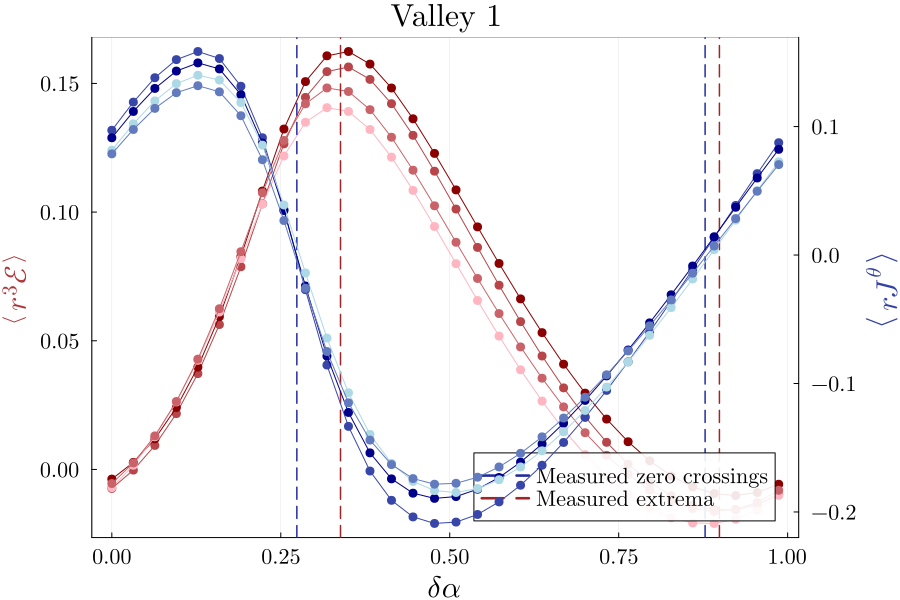

In [678]:
p = plot(size=(900,600),xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), legendfont=font("Computer Modern", 14),legend=:bottomright, titlefont=font("Computer Modern",20), background_color_legend=RGBA(1,1,1,0.9))

x_origin = 0
y_origin = 0

distances = sqrt.((H_x_distance_1[H_meas_indices].-x_origin).^2 .+ ((H_y_distance_1[H_meas_indices].-y_origin).^2))

min_dist = minimum(distances)
max_dist = maximum(distances)

power = 3
for i in H_meas_indices
    x_meas = H_x_distance_1[i]; y_meas = H_y_distance_1[i];
    distance = sqrt((x_meas-x_origin)^2+(y_meas-y_origin)^2)
    my_color = cgrad(:reds)[(distance-min_dist)/(max_dist-min_dist)]
    plot!(p,δϕs./(2*pi),(distance^power).*(v2_H_big_data_mat[i,:].-v2_y_shift),label=false,color=my_color, xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), yformatter=:plain, yguidefontcolor=cgrad(:reds)[0.7],guidefont=font("Computer Modern",20))
    scatter!(p,δϕs./(2*pi),(distance^power).*(v2_H_big_data_mat[i,:].-v2_y_shift),label=false,zcolor=distance,markerstrokewidth=0,colormap=:reds, markersize=5,colorbar=false, xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), yformatter=:plain)
end

xlabel!(p,L"\delta\alpha")
ylabel!(p,L"\left\langle r^3\mathcal{E} \right\rangle")

p_twin = twinx(p)

distances = sqrt.((x_distance_1[meas_indices].-x_origin).^2 .+ ((y_distance_1[meas_indices].-y_origin).^2))

min_dist = minimum(distances)
max_dist = maximum(distances)

max_value = -1e5; min_value = 1e5;

power = 1
for i in meas_indices
    x_meas = x_distance_1[i]; y_meas = y_distance_1[i];
    distance = sqrt((x_meas-x_origin)^2+(y_meas-y_origin)^2)
    my_color = cgrad(:blues)[(distance-min_dist)/(max_dist-min_dist)]
    plot!(p_twin,δϕs./(2*pi),-(distance^power).*(v2_big_data_mat[i,:]),label=false,color=my_color, xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), yformatter=:plain, yguidefontcolor=cgrad(:blues)[0.7],guidefont=font("Computer Modern",20))
    scatter!(p_twin,δϕs./(2*pi),-(distance^power).*(v2_big_data_mat[i,:]),label=false,zcolor=distance,markerstrokewidth=0,colormap=:blues, markersize=5,colorbar=false, xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), yformatter=:plain)

    rJθ = -(distance^power).*(v2_big_data_mat[i,:]); push!(rJθ,max_value); max_value = maximum(rJθ);
    rJθ = -(distance^power).*(v2_big_data_mat[i,:]); push!(rJθ,min_value); min_value = minimum(rJθ);
end

# ## Negative to Positive ##
vline!([circular_mean(v2_intercept_list)/(2*pi)], linestyle=:dash, color=cgrad(:blues)[0.8], label="Measured zero crossings", lw=1.5)
vline!([circular_mean(v2_min_list)/(2*pi)], linestyle=:dash, color=cgrad(:reds)[0.8], label="Measured extrema", lw=1.5)

## Positive to Negative ##
vline!([circular_mean(v2_other_intercept_list)/(2*pi)], linestyle=:dash, color=cgrad(:blues)[0.8], label=false, lw=1.5)
vline!([circular_mean(v2_max_list)/(2*pi)], linestyle=:dash, color=cgrad(:reds)[0.8], label=false, lw=1.5)

xlabel!(p_twin,"")
ylabel!(p_twin,L"\left\langle rJ^\theta \right\rangle")


title!(p,"Valley 1") # the valley labels are swapped here to match the paper
title!(p_twin,"")

push!(xs,0); push!(ys,0); push!(vals,0)
plot!(p,left_margin = 2Plots.mm,right_margin = 3Plots.mm,framestyle=:semi)

display(p)

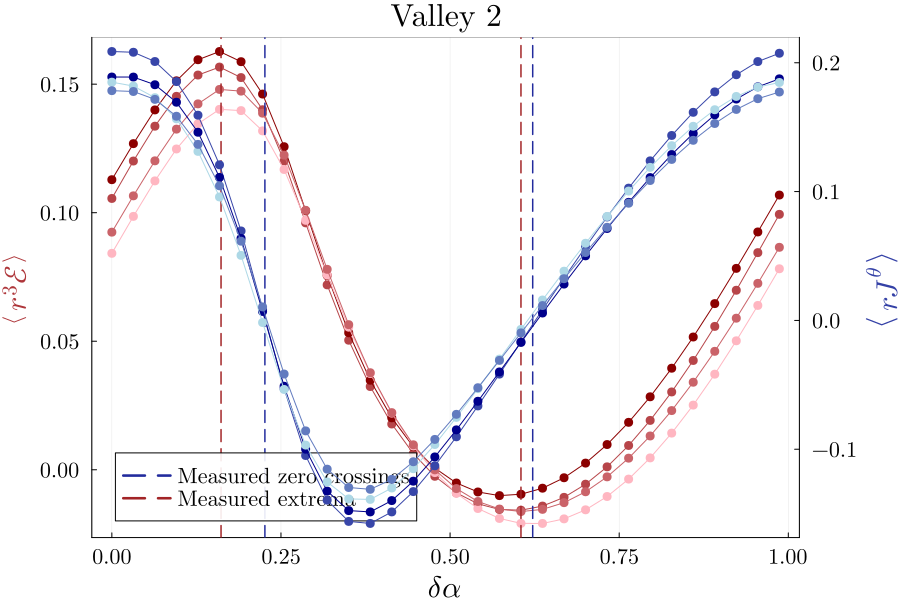

In [679]:
p = plot(size=(900,600),xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), legendfont=font("Computer Modern", 14),legend=:bottomleft,titlefont=font("Computer Modern",20), background_color_legend=RGBA(1,1,1,0.9))

x_origin = 0
y_origin = 0

distances = sqrt.((H_x_distance_1[H_meas_indices].-x_origin).^2 .+ ((H_y_distance_1[H_meas_indices].-y_origin).^2))

min_dist = minimum(distances)
max_dist = maximum(distances)

power = 3
for i in H_meas_indices
    x_meas = H_x_distance_1[i]; y_meas = H_y_distance_1[i];
    distance = sqrt((x_meas-x_origin)^2+(y_meas-y_origin)^2)
    my_color = cgrad(:reds)[(distance-min_dist)/(max_dist-min_dist)]
    plot!(p,δϕs./(2*pi),(distance^power).*(v1_H_big_data_mat[i,:].-v1_y_shift),label=false,color=my_color, xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), yformatter=:plain, yguidefontcolor=cgrad(:reds)[0.7],guidefont=font("Computer Modern",20))
    scatter!(p,δϕs./(2*pi),(distance^power).*(v1_H_big_data_mat[i,:].-v1_y_shift),label=false,zcolor=distance,markerstrokewidth=0,colormap=:reds, markersize=5,colorbar=false, xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), yformatter=:plain)
end


xlabel!(p,L"\delta\alpha")
ylabel!(p,L"\left\langle r^3\mathcal{E} \right\rangle")

p_twin = twinx(p)

distances = sqrt.((x_distance_1[meas_indices].-x_origin).^2 .+ ((y_distance_1[meas_indices].-y_origin).^2))

min_dist = minimum(distances)
max_dist = maximum(distances)

max_value = -1e5; min_value = 1e5;

power = 1
for i in meas_indices
    x_meas = x_distance_1[i]; y_meas = y_distance_1[i];
    distance = sqrt((x_meas-x_origin)^2+(y_meas-y_origin)^2)
    my_color = cgrad(:blues)[(distance-min_dist)/(max_dist-min_dist)]
    plot!(p_twin,δϕs./(2*pi),-(distance^power).*(v1_big_data_mat[i,:]),label=false,color=my_color, xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), yformatter=:plain, yguidefontcolor=cgrad(:blues)[0.7],guidefont=font("Computer Modern",20))
    scatter!(p_twin,δϕs./(2*pi),-(distance^power).*(v1_big_data_mat[i,:]),label=false,zcolor=distance,markerstrokewidth=0,colormap=:blues, markersize=5,colorbar=false, xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), yformatter=:plain)

    rJθ = -(distance^power).*(v1_big_data_mat[i,:]); push!(rJθ,max_value); max_value = maximum(rJθ);
    rJθ = -(distance^power).*(v1_big_data_mat[i,:]); push!(rJθ,min_value); min_value = minimum(rJθ);
end

spread = max_value - min_value

## Plug in ##
label_x_offset = 1-0.2
label_y_offset = 0.00*spread
line_y_offset = min_value + 0.7*spread

Δy = 0.08*spread

## Negative to Positive ##
vline!([circular_mean(v1_intercept_list)/(2*pi)], linestyle=:dash, color=cgrad(:blues)[0.8], label="Measured zero crossings", lw=1.5)
vline!([circular_mean(v1_min_list)/(2*pi)], linestyle=:dash, color=cgrad(:reds)[0.8], label="Measured extrema", lw=1.5)

## Plug in ##
label_x_offset = 1-0.53
label_y_offset = 0.03*spread
line_y_offset = min_value + 0.23*spread

## Positive to Negative ##
vline!([circular_mean(v1_other_intercept_list)/(2*pi)], linestyle=:dash, color=cgrad(:blues)[0.8], label=false, lw=1.5)
vline!([circular_mean(v1_max_list)/(2*pi)], linestyle=:dash, color=cgrad(:reds)[0.8], label=false, lw=1.5)

xlabel!(p_twin,"")
ylabel!(p_twin,L"\left\langle rJ^\theta \right\rangle")

title!(p,"Valley 2") # the valley labels are swapped here to match the paper
title!(p_twin,"")


plot!(p,left_margin = 2Plots.mm,right_margin = 3Plots.mm,framestyle=:semi)

display(p)